In [6]:
import ast
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

rooms = {
    "Room A": {
        "path": PROJECT_ROOT / "data/our_dataset/room_a/clean_data_final.csv",
        "selected_rows": (44027, 45081),
        "scenario": "scenario_1",
        "features": ["co2_value", "motion_event_count", "noise_value", "target"],
    },
    "Room B": {
        "path": PROJECT_ROOT / "data/our_dataset/room_b/clean_data_final.csv",
        "selected_rows": (40027, 41081),
        "scenario": "scenario_1",
        "features": ["co2_value", "motion_event_count", "target"],
    },
    "Room C": {
        "path": PROJECT_ROOT / "data/our_dataset/room_c/clean_data_final.csv",
        "selected_rows": (21995, 23049),
        "scenario": "scenario_2",
        "features": ["co2_value", "motion_event_count", "target"],
    },
    "Public": {
        "path": PROJECT_ROOT / "data/public_data/public_room_5min.csv",
        "selected_rows": None,
        "scenario": "scenario_1",
        "features": [
            "co2_value",
            "motion_event_count",
            "temperature",
            "light",
            "sound_relative_dbm",
            "target",
        ],
    },
}


def extract_target(val):
    try:
        return ast.literal_eval(val)[0] if isinstance(val, str) else val
    except Exception:
        return None


def split_data(df, scenario):
    n = len(df)

    if scenario == "scenario_1":
        train_end = int(0.70 * n)
        val_end = int(0.80 * n)

        train_df = df.iloc[:train_end].reset_index(drop=True)
        val_df = df.iloc[train_end:val_end].reset_index(drop=True)
        test_df = df.iloc[val_end:].reset_index(drop=True)

    elif scenario == "scenario_2":
        test_end = int(0.20 * n)
        val_end = int(0.30 * n)

        test_df = df.iloc[:test_end].reset_index(drop=True)
        val_df = df.iloc[test_end:val_end].reset_index(drop=True)
        train_df = df.iloc[val_end:].reset_index(drop=True)

    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    return train_df, val_df, test_df


def load_room_dataframe(cfg):
    df = pd.read_csv(cfg["path"])

    df = df.rename(columns={
        "co2": "co2_value",
        "motion": "motion_event_count",
    })

    if "target" not in df.columns:
        if "peoplecount_value" in df.columns:
            df["target"] = df["peoplecount_value"].apply(extract_target)

        elif "Room_Occupancy_Count" in df.columns:
            df["target"] = df["Room_Occupancy_Count"]

    if cfg["selected_rows"] is not None:
        start, end = cfg["selected_rows"]
        df = df.iloc[start:end].reset_index(drop=True)

    return df


def make_stats_table(split_name):
    rows = []

    for room_name, cfg in rooms.items():
        df = load_room_dataframe(cfg)

        train_df, val_df, test_df = split_data(df, cfg["scenario"])

        if split_name == "Train":
            split_df = train_df
        elif split_name == "Test":
            split_df = test_df
        else:
            raise ValueError("split_name must be 'Train' or 'Test'")

        for feature in cfg["features"]:
            if feature not in split_df.columns:
                print(f"Missing {feature} in {room_name} - {split_name}")
                continue

            values = pd.to_numeric(split_df[feature], errors="coerce").dropna()

            rows.append({
                "Dataset": room_name,
                "Scenario": cfg["scenario"],
                "Split": split_name,
                "Feature": feature,
                "N": len(values),
                "Mean": values.mean(),
                "Std": values.std(),
                "Min": values.min(),
                "Median": values.median(),
                "Max": values.max(),
            })

    return pd.DataFrame(rows).round(3)


train_stats_df = make_stats_table("Train")
test_stats_df = make_stats_table("Test")

print("TRAIN TABLE")
display(train_stats_df)

print("TEST TABLE")
display(test_stats_df)

TRAIN TABLE


,Dataset,Scenario,Split,Feature,N,Mean,Std,Min,Median,Max
0,Room A,scenario_1,Train,co2_value,737,484.483,90.328,429.000,458.000,952.000
1,Room A,scenario_1,Train,motion_event_count,737,26.608,52.366,0.000,0.000,185.000
2,Room A,scenario_1,Train,noise_value,737,4.102,12.777,0.000,0.000,62.000
3,Room A,scenario_1,Train,target,737,0.814,1.784,0.000,0.000,8.000
4,Room B,scenario_1,Train,co2_value,737,568.991,113.524,430.000,520.000,939.000
5,Room B,scenario_1,Train,motion_event_count,737,21.777,45.306,0.000,0.000,188.000
6,Room B,scenario_1,Train,target,737,0.560,1.169,0.000,0.000,5.000
7,Room C,scenario_2,Train,co2_value,738,496.766,66.879,427.000,476.000,863.000
8,Room C,scenario_2,Train,motion_event_count,738,5.390,20.311,0.000,0.000,139.000
9,Room C,scenario_2,Train,target,738,0.706,0.811,0.000,1.000,5.000


TEST TABLE


,Dataset,Scenario,Split,Feature,N,Mean,Std,Min,Median,Max
0,Room A,scenario_1,Test,co2_value,211,495.213,104.228,429.000,442.000,849.000
1,Room A,scenario_1,Test,motion_event_count,211,30.270,56.732,0.000,0.000,181.000
2,Room A,scenario_1,Test,noise_value,211,3.810,12.095,0.000,0.000,54.000
3,Room A,scenario_1,Test,target,211,0.640,1.353,0.000,0.000,5.000
4,Room B,scenario_1,Test,co2_value,211,575.299,116.931,452.000,510.000,864.000
5,Room B,scenario_1,Test,motion_event_count,211,30.687,49.083,0.000,0.000,170.000
6,Room B,scenario_1,Test,target,211,0.768,1.218,0.000,0.000,3.000
7,Room C,scenario_2,Test,co2_value,210,565.386,130.664,431.000,509.000,927.000
8,Room C,scenario_2,Test,motion_event_count,210,17.457,41.962,0.000,0.000,178.000
9,Room C,scenario_2,Test,target,210,1.233,1.639,0.000,1.000,8.000


In [5]:
import ast
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

room_paths = {
    "A": PROJECT_ROOT / "data/our_dataset/room_a/clean_data_final.csv",
    "B": PROJECT_ROOT / "data/our_dataset/room_b/clean_data_final.csv",
    "C": PROJECT_ROOT / "data/our_dataset/room_c/clean_data_final.csv",
    "P": PROJECT_ROOT / "data/public_data/public_room_5min.csv",
}

selected_rows = {
    "A": (44027, 45081),
    "B": (40027, 41081),
    "C": (21995, 23049),
    "P": None,
}


def extract_target(val):
    try:
        return ast.literal_eval(val)[0] if isinstance(val, str) else val
    except Exception:
        return None


def load_data(room_id, path):
    df = pd.read_csv(path)

    df = df.rename(columns={
        "co2": "co2_value",
        "motion": "motion_event_count",
    })

    if "target" not in df.columns:
        if "peoplecount_value" in df.columns:
            df["target"] = df["peoplecount_value"].apply(extract_target)
        elif "Room_Occupancy_Count" in df.columns:
            df["target"] = df["Room_Occupancy_Count"]

    df["target"] = pd.to_numeric(df["target"], errors="coerce")
    df = df.dropna(subset=["target"]).reset_index(drop=True)

    if selected_rows[room_id] is not None:
        start, end = selected_rows[room_id]
        df = df.iloc[start:end].reset_index(drop=True)

    return df


def get_splits(df, scenario):
    n = len(df)

    if scenario == 1:
        train_end = int(0.70 * n)
        val_end = int(0.80 * n)

        train = df.iloc[:train_end]
        val = df.iloc[train_end:val_end]
        test = df.iloc[val_end:]

    elif scenario == 2:
        test_end = int(0.20 * n)
        val_end = int(0.30 * n)

        test = df.iloc[:test_end]
        val = df.iloc[test_end:val_end]
        train = df.iloc[val_end:]

    else:
        raise ValueError("scenario must be 1 or 2")

    return train, val, test


def print_people_table(train, test):
    train_counts = train["target"].astype(int).value_counts().sort_index()
    test_counts = test["target"].astype(int).value_counts().sort_index()

    labels = sorted(set(train_counts.index) | set(test_counts.index))

    print(f"{'People':<10} | {'Train Count':<14} | {'Train %':<12} | {'Test Count':<14} | {'Test %':<12}")
    print("-" * 78)

    for label in labels:
        train_count = train_counts.get(label, 0)
        test_count = test_counts.get(label, 0)

        train_pct = train_count / len(train) * 100 if len(train) > 0 else 0
        test_pct = test_count / len(test) * 100 if len(test) > 0 else 0

        print(
            f"{label:<10} | "
            f"{train_count:<14} | {train_pct:<11.2f}% | "
            f"{test_count:<14} | {test_pct:<11.2f}%"
        )

    print("-" * 78)
    print(
        f"{'TOTAL':<10} | "
        f"{len(train):<14} | {100:<11.2f}% | "
        f"{len(test):<14} | {100:<11.2f}%"
    )


for room_id, path in room_paths.items():
    df = load_data(room_id, path)

    room_name = "Public" if room_id == "P" else f"Room {room_id}"

    print("\n" + "=" * 90)
    print(f"{room_name}")
    print(f"Total selected samples: {len(df)}")
    print("=" * 90)

    for scenario in [1, 2]:
        train, val, test = get_splits(df, scenario)

        if scenario == 1:
            print("\nSCENARIO 1: TRAIN FIRST (70%) + VALIDATION MIDDLE (10%) + TEST END (20%)")
        else:
            print("\nSCENARIO 2: TEST FIRST (20%) + VALIDATION MIDDLE (10%) + TRAIN END (70%)")

        print(f"Train: {len(train)} samples | Validation: {len(val)} samples | Test: {len(test)} samples\n")

        print_people_table(train, test)


Room A
Total selected samples: 1054

SCENARIO 1: TRAIN FIRST (70%) + VALIDATION MIDDLE (10%) + TEST END (20%)
Train: 737 samples | Validation: 106 samples | Test: 211 samples

People     | Train Count    | Train %      | Test Count     | Test %      
------------------------------------------------------------------------------
0          | 564            | 76.53      % | 161            | 76.30      %
1          | 36             | 4.88       % | 8              | 3.79       %
2          | 31             | 4.21       % | 26             | 12.32      %
3          | 38             | 5.16       % | 2              | 0.95       %
4          | 16             | 2.17       % | 1              | 0.47       %
5          | 20             | 2.71       % | 13             | 6.16       %
6          | 2              | 0.27       % | 0              | 0.00       %
7          | 28             | 3.80       % | 0              | 0.00       %
8          | 2              | 0.27       % | 0              | 0.00   

Marginal Shift

Loading TRAIN data only...
  Room A: 737 TRAIN samples - OK
  Room B: 737 TRAIN samples - OK
  Room C: 738 TRAIN samples - OK
  Public: 737 TRAIN samples - OK

MARGINAL SHIFT ANALYSIS


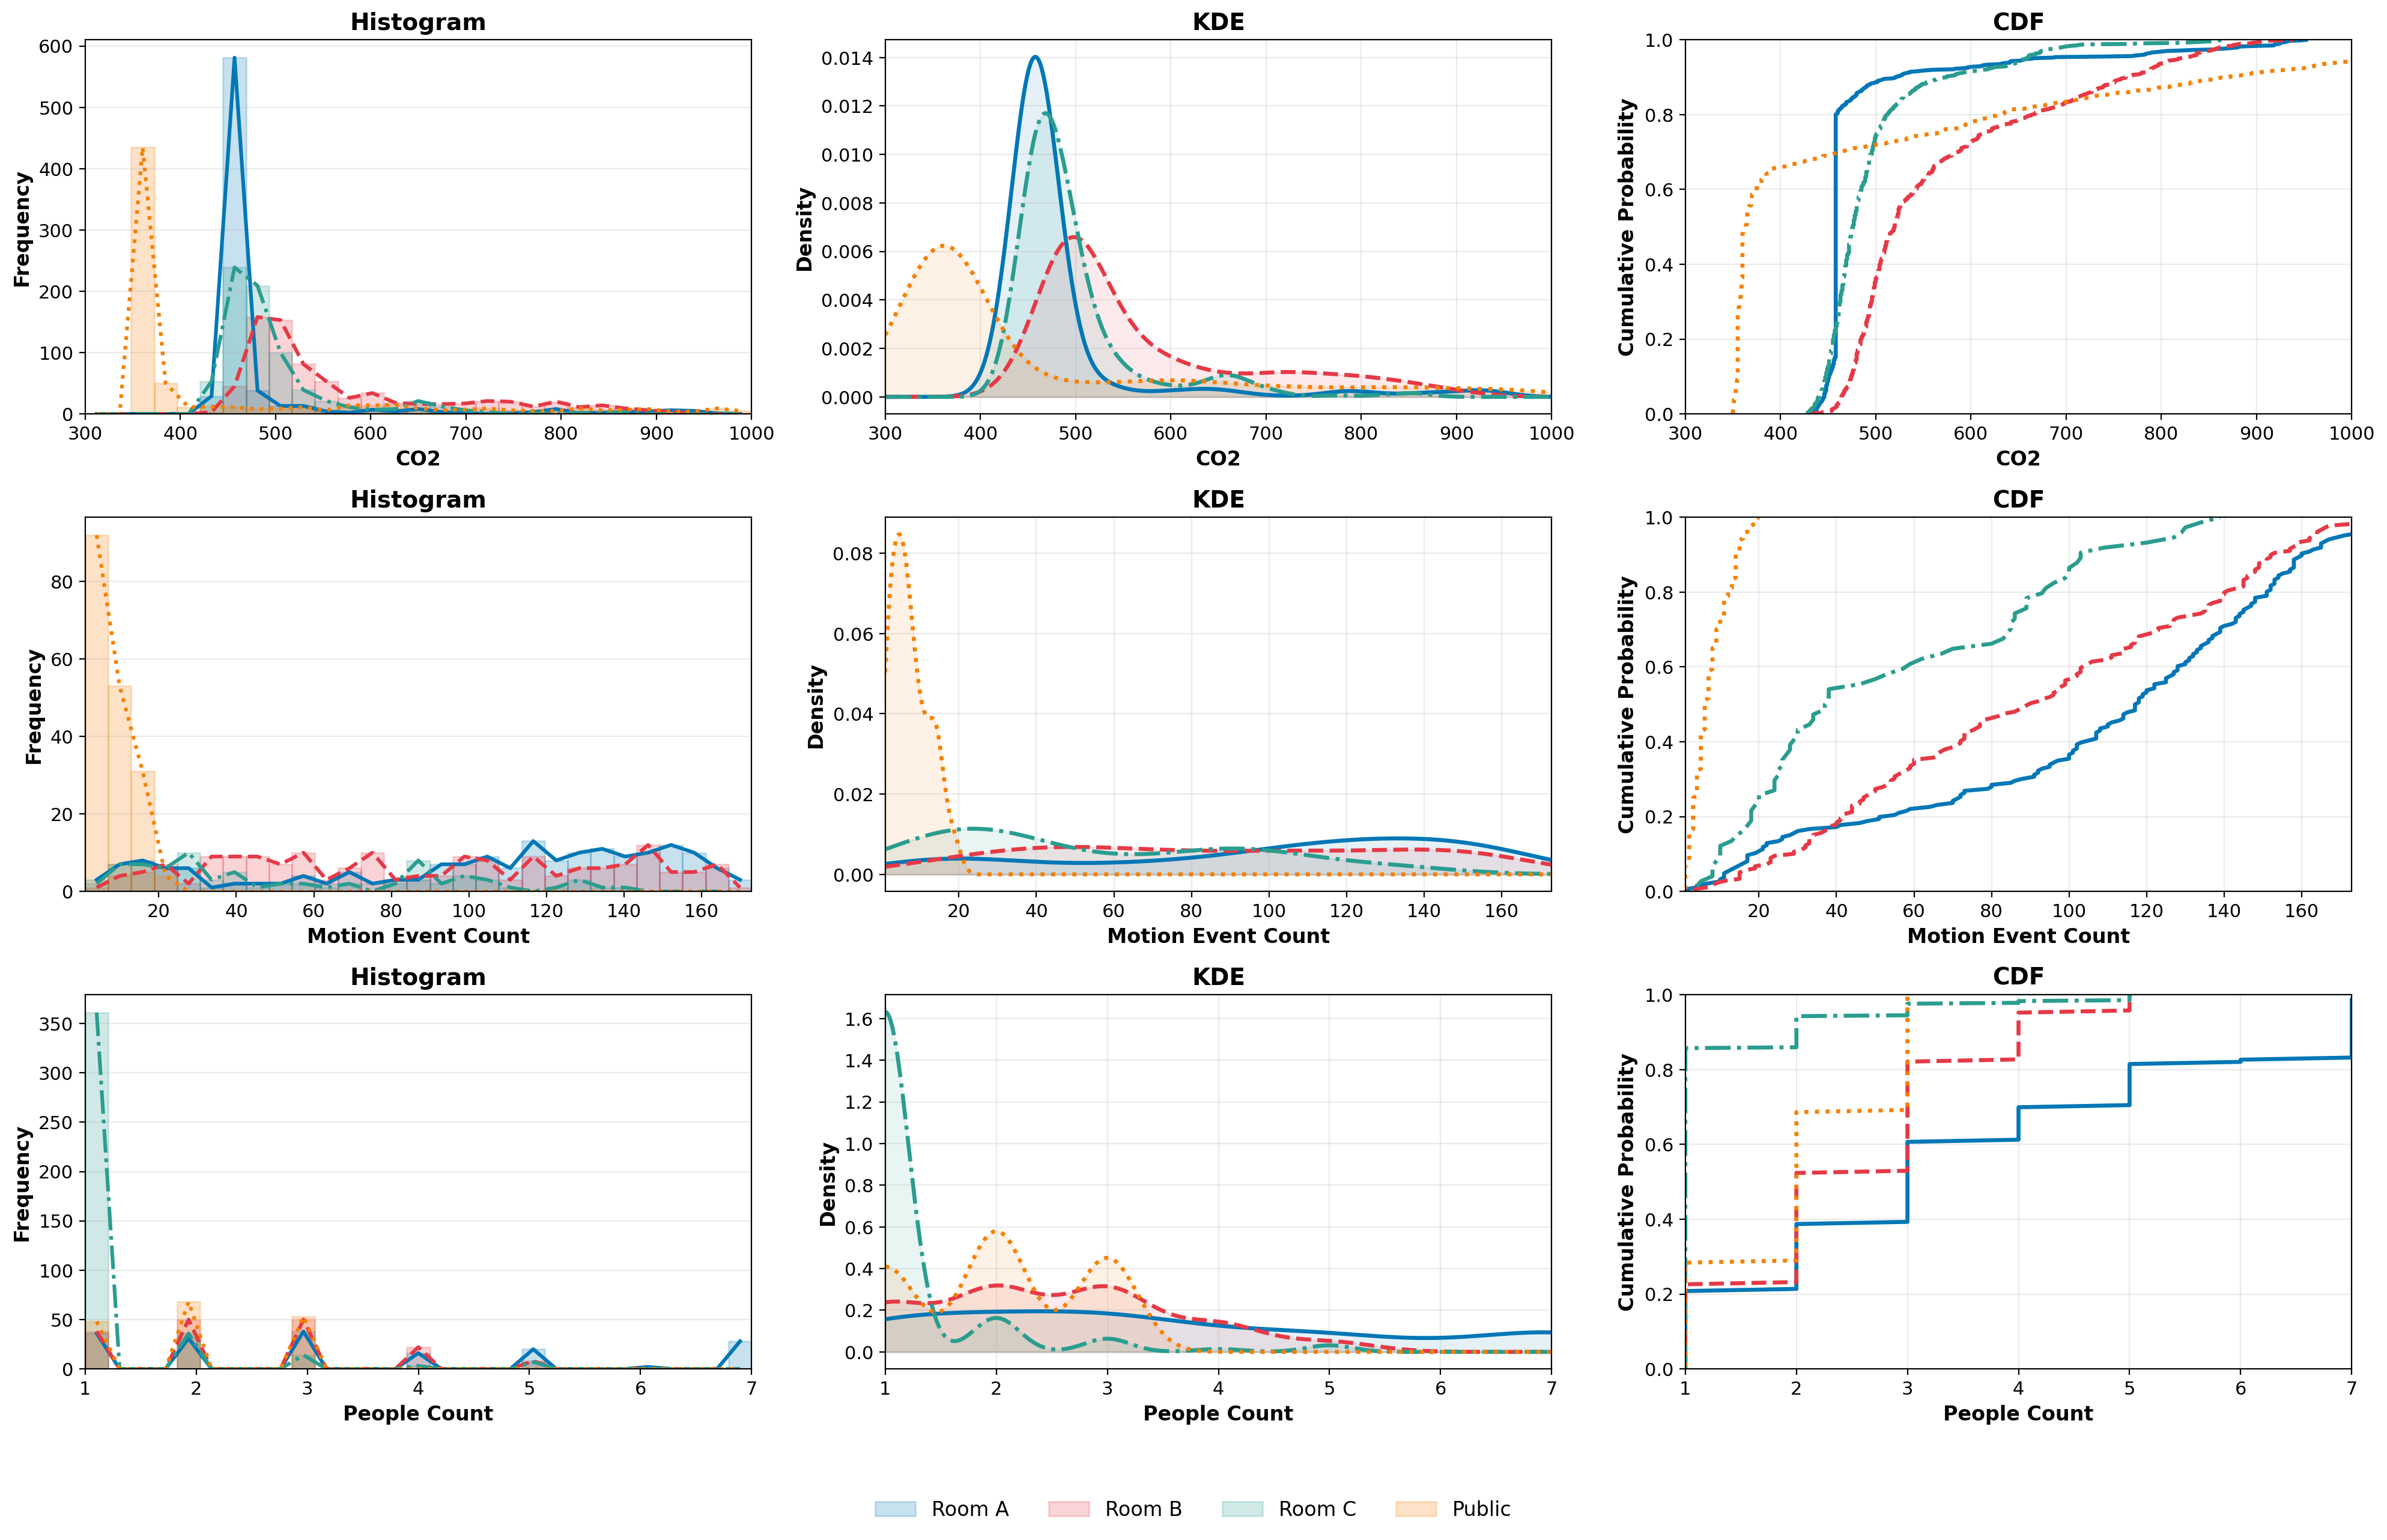

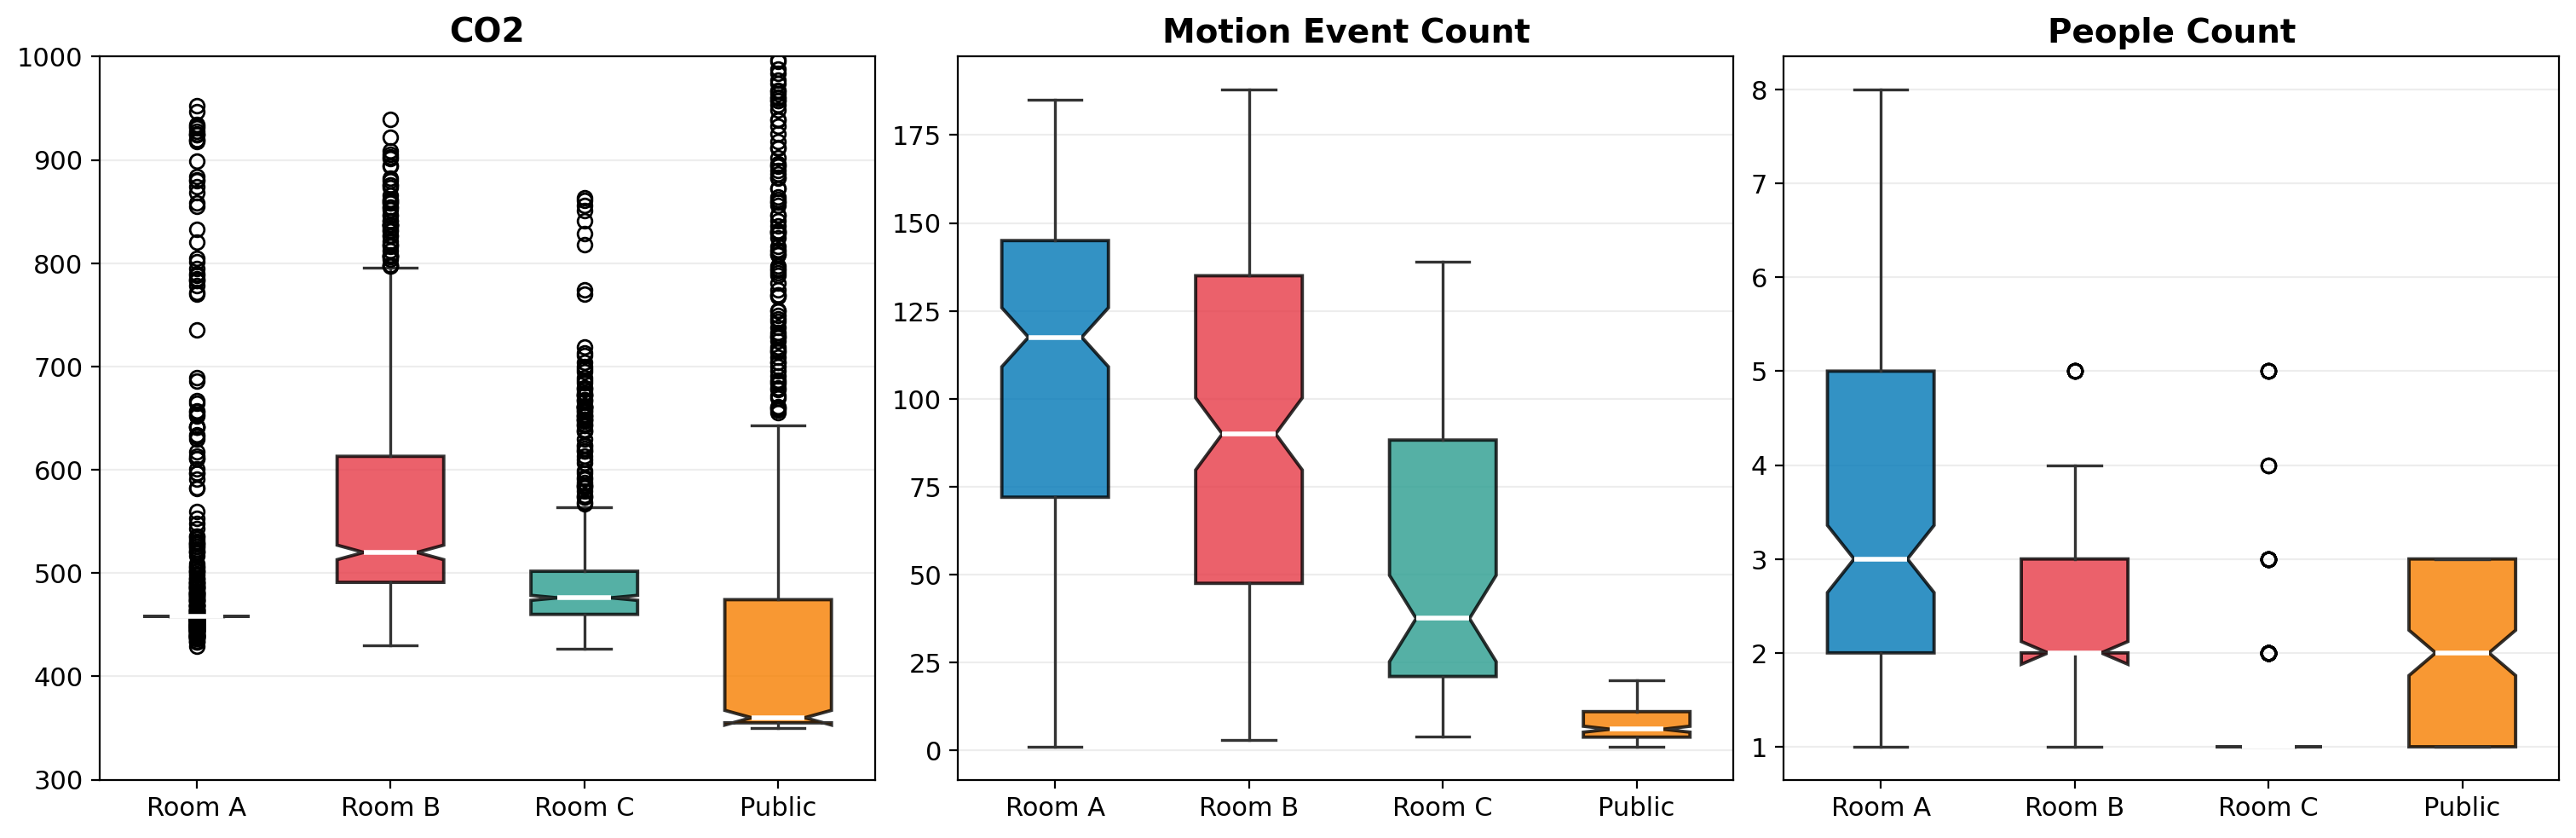

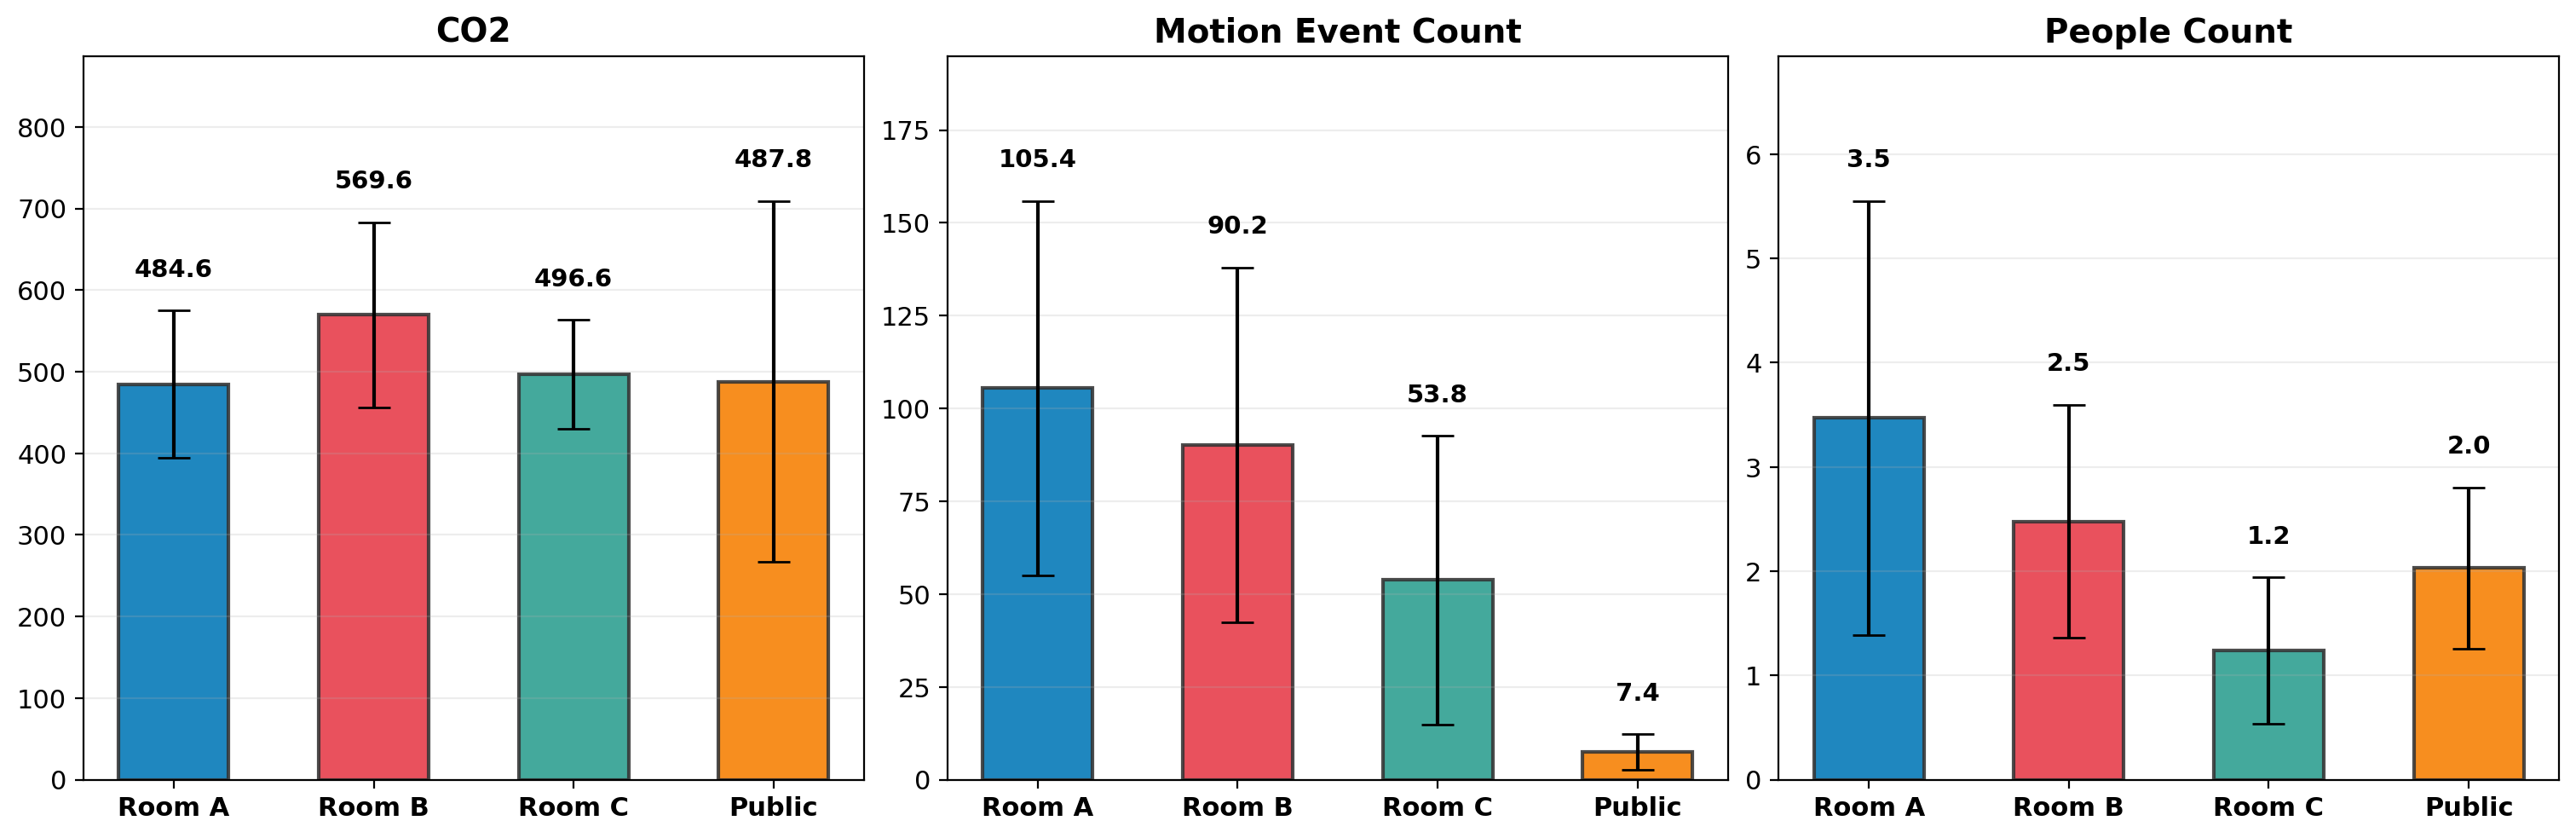

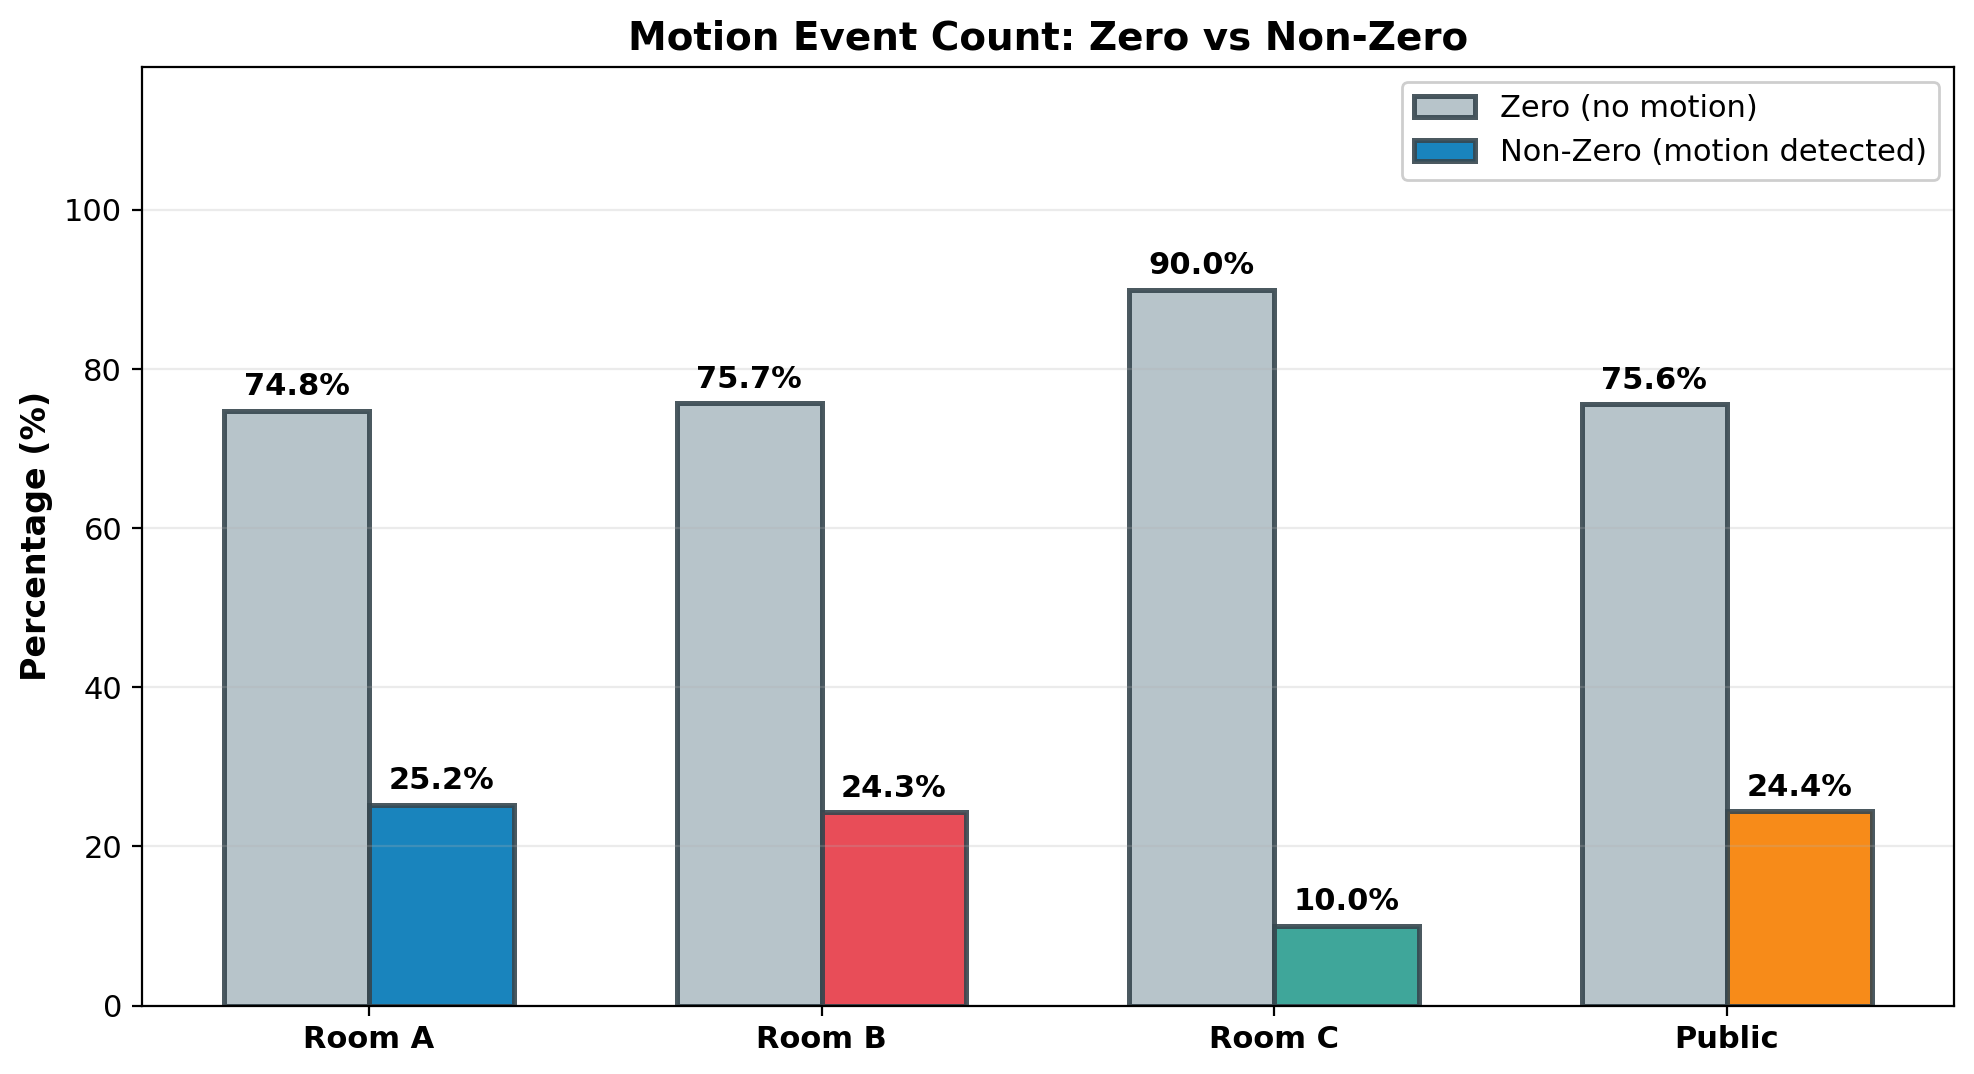

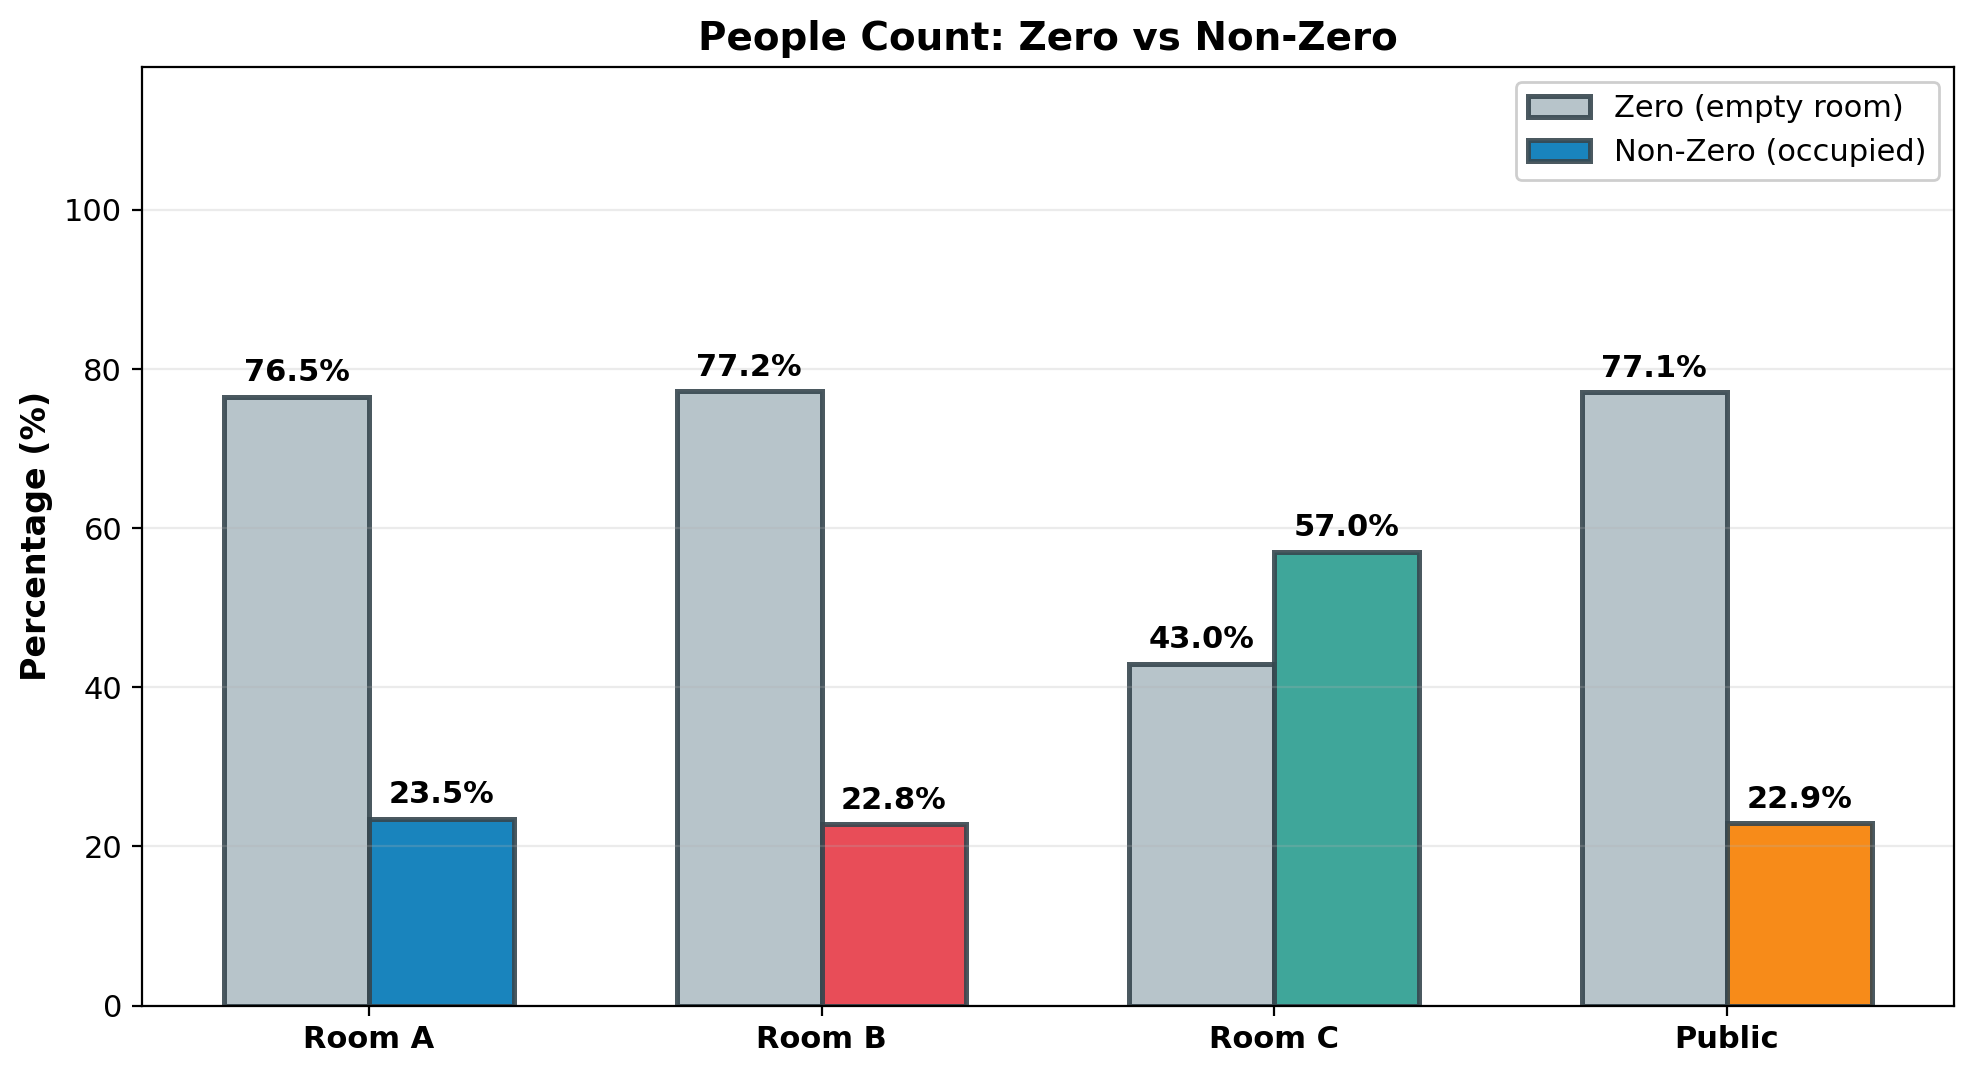


MARGINAL SHIFT DETECTION - STATISTICS TABLE

CO2_VALUE
Comparison      | Mean Src   | Std Src    | Mean Tgt   | Std Tgt    | KS Stat    | P-value      | SMD      | MMD²     | MMD lvl    | Significant? | Effect Size 
------------------------------------------------------------------------------------------------------------------------------------------------------
Room A → B       | 484.62     | 90.31      | 569.58     | 113.63     | 0.7829     | 0.000000     | 0.828    | 0.4163   | Large      | YES          | Large       
Room A → C       | 484.62     | 90.31      | 496.63     | 66.86      | 0.5675     | 0.000000     | 0.151    | 0.1871   | Large      | YES          | Negligible  
Room A → P(Pub)  | 484.62     | 90.31      | 487.82     | 221.21     | 0.6798     | 0.000000     | 0.019    | 0.6753   | Large      | YES          | Negligible  
Room B → C       | 569.58     | 113.63     | 496.63     | 66.86      | 0.4035     | 0.000000     | 0.783    | 0.1512   | Large      | YES         

In [8]:
"""
Focused Marginal Shift Visualization — PAPER PANEL VERSION
"""

import os
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, gaussian_kde
from pathlib import Path

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 200,
    "savefig.dpi": 600
})

ROOM_COLORS = {
    'A': '#0077B6',
    'B': '#E63946',
    'C': '#2A9D8F',
    'P': '#F77F00'
}

ROOM_LINES = {
    'A': '-',
    'B': '--',
    'C': '-.',
    'P': ':'
}

FEATURE_PLOT_RANGE = {
    'co2_value': (300, 1000),
    'motion_event_count': None
}

SELECTED_ROWS = {
    'A': (44027, 45081),
    'B': (40027, 41081),
    'C': (21995, 23049),
    'P': None
}

SCENARIOS = {
    'A': 'scenario_1',
    'B': 'scenario_1',
    'C': 'scenario_2',
    'P': 'scenario_1'
}

PROJECT_ROOT = Path.cwd().parent

room_paths = {
    'A': PROJECT_ROOT / "data" / "our_dataset" / "room_a" / "clean_data_final.csv",
    'B': PROJECT_ROOT / "data" / "our_dataset" / "room_b" / "clean_data_final.csv",
    'C': PROJECT_ROOT / "data" / "our_dataset" / "room_c" / "clean_data_final.csv",
}

public_data_path = PROJECT_ROOT / "data" / "public_data" / "public_room_5min.csv"

OUTPUT_DIR = PROJECT_ROOT / "results" / "marginal_shift"


def room_label(room):
    return f"Room {room}" if room != 'P' else "Public"


def room_label_short(room):
    return f"Room {room}" if room != 'P' else "Public"


def parse_peoplecount_value(x):
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, (list, tuple)) and len(parsed) > 0:
                    return float(parsed[0])
            except (ValueError, SyntaxError):
                return 0.0
    try:
        return float(x)
    except (TypeError, ValueError):
        return 0.0


def load_data(file_path, selected_rows=None):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_csv(file_path)

    if 'peoplecount_value' not in df.columns:
        raise KeyError(f"'peoplecount_value' column not found in {file_path}")

    df['target'] = df['peoplecount_value'].apply(parse_peoplecount_value)
    df['co2_value'] = pd.to_numeric(df['co2_value'], errors='coerce')
    df['motion_event_count'] = pd.to_numeric(df['motion_event_count'], errors='coerce')
    df['target'] = pd.to_numeric(df['target'], errors='coerce')

    if 'noise_value' in df.columns:
        df['noise_value'] = pd.to_numeric(df['noise_value'], errors='coerce')

    df = df.dropna(subset=['co2_value', 'motion_event_count', 'target'])

    if selected_rows is not None:
        start, end = selected_rows
        df = df.iloc[start:end].reset_index(drop=True)

    return df


def load_public_data(file_path, selected_rows=None):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_csv(file_path)

    df = df.rename(columns={
        'co2': 'co2_value',
        'motion': 'motion_event_count'
    })

    required = ['co2_value', 'motion_event_count', 'target']
    for col in required:
        if col not in df.columns:
            raise KeyError(f"'{col}' column not found in public dataset: {file_path}")

    df['co2_value'] = pd.to_numeric(df['co2_value'], errors='coerce')
    df['motion_event_count'] = pd.to_numeric(df['motion_event_count'], errors='coerce')
    df['target'] = pd.to_numeric(df['target'], errors='coerce')

    for col in ['sound', 'temperature', 'light']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['co2_value', 'motion_event_count', 'target'])

    if selected_rows is not None:
        start, end = selected_rows
        df = df.iloc[start:end].reset_index(drop=True)

    return df


def get_train_split(df, scenario):
    n = len(df)

    if scenario == "scenario_1":
        train_end = int(0.7 * n)
        return df.iloc[:train_end].reset_index(drop=True)

    elif scenario == "scenario_2":
        train_start = int(0.3 * n)
        return df.iloc[train_start:].reset_index(drop=True)

    else:
        raise ValueError(f"Unknown scenario: {scenario}")


def load_all_rooms():
    rooms = {}
    print("Loading TRAIN data only...")

    for room_id, path in room_paths.items():
        try:
            df = load_data(path, selected_rows=SELECTED_ROWS[room_id])
            df = get_train_split(df, SCENARIOS[room_id])

            rooms[room_id] = df
            print(f"  {room_label(room_id)}: {len(df)} TRAIN samples - OK")

        except Exception as e:
            print(f"  {room_label(room_id)}: ERROR - {e}")

    try:
        df = load_public_data(public_data_path, selected_rows=SELECTED_ROWS['P'])
        df = get_train_split(df, SCENARIOS['P'])

        rooms['P'] = df
        print(f"  {room_label('P')}: {len(df)} TRAIN samples - OK")

    except Exception as e:
        print(f"  {room_label('P')}: ERROR - {e}")

    if len(rooms) < 2:
        raise SystemExit("ERROR: Need at least 2 successfully loaded datasets.")

    return rooms


def calculate_shift_metrics(data1, data2):
    ks_stat, ks_pval = ks_2samp(data1, data2)

    mean1, mean2 = data1.mean(), data2.mean()
    std1, std2 = data1.std(), data2.std()

    pooled_std = np.sqrt((std1**2 + std2**2) / 2)
    smd = abs(mean2 - mean1) / pooled_std if pooled_std > 0 else 0.0

    ks_sig = "YES" if ks_pval < 0.05 else "NO"

    if smd < 0.2:
        smd_level = "Negligible"
    elif smd < 0.5:
        smd_level = "Small"
    elif smd < 0.8:
        smd_level = "Moderate"
    else:
        smd_level = "Large"

    return {
        'ks_stat': ks_stat,
        'ks_pval': ks_pval,
        'ks_sig': ks_sig,
        'smd': smd,
        'smd_level': smd_level,
        'mean1': mean1,
        'mean2': mean2,
        'std1': std1,
        'std2': std2
    }


# ============================================================
# MMD — Maximum Mean Discrepancy (RBF kernel, median heuristic)
# ============================================================
def compute_mmd_rbf(data1, data2, n_subsample=2000, standardize=True, seed=42):
    """
    Squared MMD between two samples using an RBF kernel with the
    median-heuristic bandwidth (Gretton et al., 2012).

        MMD²(P, Q) = E[k(x,x')] + E[k(y,y')] - 2·E[k(x,y)]

    - Accepts 1D arrays (single feature) or 2D arrays (multi-feature).
    - Standardizes on combined data (recommended for cross-feature comparisons).
    - Subsamples for tractability (kernel matrices are O(n²)).

    Returns (mmd2, sigma).
    """
    rng = np.random.default_rng(seed)

    x = np.asarray(data1, dtype=np.float64)
    y = np.asarray(data2, dtype=np.float64)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    if y.ndim == 1:
        y = y.reshape(-1, 1)

    # Standardize on combined data so MMD is comparable across features
    if standardize:
        combined = np.vstack([x, y])
        mu = combined.mean(axis=0)
        sd = combined.std(axis=0) + 1e-8
        x = (x - mu) / sd
        y = (y - mu) / sd

    # Subsample to keep memory manageable
    if len(x) > n_subsample:
        x = x[rng.choice(len(x), n_subsample, replace=False)]
    if len(y) > n_subsample:
        y = y[rng.choice(len(y), n_subsample, replace=False)]

    # Median-heuristic bandwidth on a (sub)sample of the union
    z = np.vstack([x, y])
    m = min(len(z), 1000)
    zs = z[rng.choice(len(z), m, replace=False)] if len(z) > m else z
    d2 = ((zs[:, None, :] - zs[None, :, :]) ** 2).sum(-1)
    med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
    sigma2 = med / 2 if med > 0 else 1.0

    def rbf(a, b):
        dist2 = ((a[:, None, :] - b[None, :, :]) ** 2).sum(-1)
        return np.exp(-dist2 / (2 * sigma2))

    Kxx = rbf(x, x).mean()
    Kyy = rbf(y, y).mean()
    Kxy = rbf(x, y).mean()
    mmd2 = float(Kxx + Kyy - 2 * Kxy)
    return mmd2, float(np.sqrt(sigma2))


def mmd_level(mmd2):
    """Rough effect-size bins for standardized MMD²."""
    if mmd2 < 0.01:
        return "Negligible"
    elif mmd2 < 0.05:
        return "Small"
    elif mmd2 < 0.15:
        return "Moderate"
    else:
        return "Large"


def draw_hist_kde_cdf_row(feature_name, data_dict, axes, plot_range=None):
    available_rooms = sorted(data_dict.keys())
    ax_hist, ax_kde, ax_cdf = axes

    all_data = np.concatenate([data_dict[r] for r in available_rooms if len(data_dict[r]) > 0])

    if plot_range:
        lo, hi = plot_range
    else:
        lo, hi = np.percentile(all_data, 1), np.percentile(all_data, 99)

    bins = np.linspace(lo, hi, 30)
    x_range = np.linspace(lo, hi, 500)

    for room in available_rooms:
        data = data_dict[room]
        data_viz = data[(data >= lo) & (data <= hi)] if plot_range else data
        if len(data_viz) == 0:
            continue

        ax_hist.hist(
            data_viz,
            bins=bins,
            color=ROOM_COLORS[room],
            alpha=0.22,
            edgecolor=ROOM_COLORS[room],
            linewidth=1.0,
            label=room_label(room)
        )

        counts, bin_edges = np.histogram(data_viz, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        ax_hist.plot(
            bin_centers,
            counts,
            color=ROOM_COLORS[room],
            linestyle=ROOM_LINES[room],
            linewidth=2.2
        )

    ax_hist.set_title('Histogram', fontweight='bold')
    ax_hist.set_xlabel(feature_name, fontweight='bold')
    ax_hist.set_ylabel('Frequency', fontweight='bold')
    ax_hist.grid(True, alpha=0.25, axis='y')

    if plot_range:
        ax_hist.set_xlim(plot_range)

    for room in available_rooms:
        data = data_dict[room]
        data_viz = data[(data >= lo) & (data <= hi)] if plot_range else data
        if len(data_viz) < 2:
            continue

        try:
            kde = gaussian_kde(data_viz, bw_method='scott')
            density = kde(x_range)
        except np.linalg.LinAlgError:
            jitter = np.random.normal(0, max((hi - lo) * 1e-4, 1e-6), size=len(data_viz))
            kde = gaussian_kde(data_viz + jitter, bw_method='scott')
            density = kde(x_range)

        ax_kde.plot(
            x_range,
            density,
            color=ROOM_COLORS[room],
            linestyle=ROOM_LINES[room],
            linewidth=2.4
        )

        ax_kde.fill_between(x_range, density, color=ROOM_COLORS[room], alpha=0.10)

    ax_kde.set_title('KDE', fontweight='bold')
    ax_kde.set_xlabel(feature_name, fontweight='bold')
    ax_kde.set_ylabel('Density', fontweight='bold')
    ax_kde.grid(True, alpha=0.25)

    if plot_range:
        ax_kde.set_xlim(plot_range)

    for room in available_rooms:
        data = data_dict[room]
        if len(data) == 0:
            continue

        x_sorted = np.sort(data)
        cdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)

        ax_cdf.plot(
            x_sorted,
            cdf,
            color=ROOM_COLORS[room],
            linestyle=ROOM_LINES[room],
            linewidth=2.4
        )

    ax_cdf.set_title('CDF', fontweight='bold')
    ax_cdf.set_xlabel(feature_name, fontweight='bold')
    ax_cdf.set_ylabel('Cumulative Probability', fontweight='bold')
    ax_cdf.set_ylim([0, 1])
    ax_cdf.grid(True, alpha=0.25)

    if plot_range:
        ax_cdf.set_xlim(plot_range)


def draw_single_boxplot(ax, feature_name, data_dict, plot_range=None):
    available_rooms = sorted(data_dict.keys())
    labels = [room_label_short(r) for r in available_rooms]

    if plot_range:
        data_list = [
            data_dict[r][(data_dict[r] >= plot_range[0]) & (data_dict[r] <= plot_range[1])]
            for r in available_rooms
        ]
    else:
        data_list = [data_dict[r] for r in available_rooms]

    bp = ax.boxplot(
        data_list,
        labels=labels,
        patch_artist=True,
        widths=0.55,
        notch=True,
        showfliers=True
    )

    for patch, room in zip(bp['boxes'], available_rooms):
        patch.set_facecolor(ROOM_COLORS[room])
        patch.set_alpha(0.8)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.4)

    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(2.0)

    for whisker in bp['whiskers']:
        whisker.set_linewidth(1.2)
        whisker.set_color('#333333')

    for cap in bp['caps']:
        cap.set_linewidth(1.2)
        cap.set_color('#333333')

    ax.set_title(feature_name, fontweight='bold')
    ax.grid(alpha=0.22, axis='y')

    if plot_range:
        ax.set_ylim(plot_range)


def draw_single_meanstd(ax, feature_name, data_dict):
    available_rooms = sorted(data_dict.keys())
    labels = [room_label_short(r) for r in available_rooms]

    means = [data_dict[r].mean() for r in available_rooms]
    stds = [data_dict[r].std() for r in available_rooms]
    x_pos = np.arange(len(available_rooms))

    bars = ax.bar(
        x_pos,
        means,
        yerr=stds,
        capsize=7,
        alpha=0.88,
        color=[ROOM_COLORS[r] for r in available_rooms],
        edgecolor='#333333',
        linewidth=1.5,
        width=0.55,
        error_kw={'linewidth': 1.5, 'color': '#333333'}
    )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontweight='bold')
    ax.set_title(feature_name, fontweight='bold')
    ax.grid(alpha=0.22, axis='y')

    ymax = max(m + s for m, s in zip(means, stds))
    ymin = min(0, min(m - s for m, s in zip(means, stds)))
    yrange = ymax - ymin if ymax > ymin else 1.0

    ax.set_ylim(ymin, ymax + 0.25 * yrange)

    for bar, mean, std in zip(bars, means, stds):
        x = bar.get_x() + bar.get_width() / 2
        y = mean + std + 0.05 * yrange

        ax.text(
            x,
            y,
            f'{mean:.1f}',
            ha='center',
            va='bottom',
            fontsize=10.5,
            fontweight='bold'
        )


def plot_triplet_panel_paper(rooms, save=False, outdir="."):
    available_rooms = sorted(rooms.keys())

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(20, 13),
        constrained_layout=False
    )

    co2_data = {r: rooms[r]['co2_value'].values for r in available_rooms}

    draw_hist_kde_cdf_row(
        'CO2',
        co2_data,
        axes[0, :],
        plot_range=(300, 1000)
    )

    motion_nz = {}

    for r in available_rooms:
        d = rooms[r]['motion_event_count'].values
        motion_nz[r] = d[d > 0]

    motion_nz = {r: v for r, v in motion_nz.items() if len(v) > 0}

    if len(motion_nz) >= 2:
        all_motion = np.concatenate(list(motion_nz.values()))
        motion_range = (np.percentile(all_motion, 1), np.percentile(all_motion, 98))

        draw_hist_kde_cdf_row(
            'Motion Event Count',
            motion_nz,
            axes[1, :],
            plot_range=motion_range
        )

    people_nz = {}

    for r in available_rooms:
        d = rooms[r]['target'].values
        people_nz[r] = d[d > 0]

    people_nz = {r: v for r, v in people_nz.items() if len(v) > 0}

    if len(people_nz) >= 2:
        all_people = np.concatenate(list(people_nz.values()))
        people_range = (np.percentile(all_people, 1), np.percentile(all_people, 98))

        draw_hist_kde_cdf_row(
            'People Count',
            people_nz,
            axes[2, :],
            plot_range=people_range
        )

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc='lower center',
        ncol=4,
        fontsize=12,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01)
    )

    plt.tight_layout(rect=[0, 0.07, 1, 1])

    if save:
        os.makedirs(outdir, exist_ok=True)

        fig.savefig(os.path.join(outdir, "figure1_triplet_3x3.pdf"), dpi=600, bbox_inches='tight')
        fig.savefig(os.path.join(outdir, "figure1_triplet_3x3.png"), dpi=600, bbox_inches='tight')
        fig.savefig(os.path.join(outdir, "figure1_triplet_3x3.tiff"), dpi=600, bbox_inches='tight')

    plt.show()


def plot_box_panel_paper(rooms, save=False, outdir="."):
    available_rooms = sorted(rooms.keys())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

    co2_data = {r: rooms[r]['co2_value'].values for r in available_rooms}

    draw_single_boxplot(
        ax=axes[0],
        feature_name='CO2',
        data_dict=co2_data,
        plot_range=(300, 1000)
    )

    motion_nz = {
        r: rooms[r]['motion_event_count'].values[rooms[r]['motion_event_count'].values > 0]
        for r in available_rooms
    }

    motion_nz = {r: v for r, v in motion_nz.items() if len(v) > 0}

    draw_single_boxplot(
        ax=axes[1],
        feature_name='Motion Event Count',
        data_dict=motion_nz,
        plot_range=None
    )

    people_nz = {
        r: rooms[r]['target'].values[rooms[r]['target'].values > 0]
        for r in available_rooms
    }

    people_nz = {r: v for r, v in people_nz.items() if len(v) > 0}

    draw_single_boxplot(
        ax=axes[2],
        feature_name='People Count',
        data_dict=people_nz,
        plot_range=None
    )

    if save:
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(os.path.join(outdir, "figure2_boxplots_1x3.pdf"), dpi=300, bbox_inches='tight')
        fig.savefig(os.path.join(outdir, "figure2_boxplots_1x3.png"), dpi=300, bbox_inches='tight')

    plt.show()


def plot_mean_panel_paper(rooms, save=False, outdir="."):
    available_rooms = sorted(rooms.keys())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

    co2_data = {r: rooms[r]['co2_value'].values for r in available_rooms}

    draw_single_meanstd(
        ax=axes[0],
        feature_name='CO2',
        data_dict=co2_data
    )

    motion_nz = {
        r: rooms[r]['motion_event_count'].values[rooms[r]['motion_event_count'].values > 0]
        for r in available_rooms
    }

    motion_nz = {r: v for r, v in motion_nz.items() if len(v) > 0}

    draw_single_meanstd(
        ax=axes[1],
        feature_name='Motion Event Count',
        data_dict=motion_nz
    )

    people_nz = {
        r: rooms[r]['target'].values[rooms[r]['target'].values > 0]
        for r in available_rooms
    }

    people_nz = {r: v for r, v in people_nz.items() if len(v) > 0}

    draw_single_meanstd(
        ax=axes[2],
        feature_name='People Count',
        data_dict=people_nz
    )

    if save:
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(os.path.join(outdir, "figure3_meanstd_1x3.pdf"), dpi=300, bbox_inches='tight')
        fig.savefig(os.path.join(outdir, "figure3_meanstd_1x3.png"), dpi=300, bbox_inches='tight')

    plt.show()


def plot_zero_percentage(
    feature_display,
    zero_counts,
    total_counts,
    available_rooms,
    zero_label='Zero',
    nonzero_label='Non-Zero',
    save_path=None
):
    fig, ax = plt.subplots(figsize=(10, 5.5))

    x_pos = np.arange(len(available_rooms))
    bar_width = 0.32

    pct_zeros = [zero_counts[r] / total_counts[r] * 100 for r in available_rooms]
    pct_nonzeros = [100 - p for p in pct_zeros]

    bars_zero = ax.bar(
        x_pos - bar_width / 2,
        pct_zeros,
        bar_width,
        color='#B0BEC5',
        edgecolor='#37474F',
        linewidth=1.8,
        label=zero_label,
        alpha=0.9
    )

    bars_nonzero = ax.bar(
        x_pos + bar_width / 2,
        pct_nonzeros,
        bar_width,
        color=[ROOM_COLORS[r] for r in available_rooms],
        edgecolor='#37474F',
        linewidth=1.8,
        label=nonzero_label,
        alpha=0.9
    )

    for bar, pct in zip(bars_zero, pct_zeros):
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 1.2,
            f'{pct:.1f}%',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    for bar, pct in zip(bars_nonzero, pct_nonzeros):
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 1.2,
            f'{pct:.1f}%',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels([room_label_short(r) for r in available_rooms], fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontweight='bold')
    ax.set_title(f'{feature_display}: Zero vs Non-Zero', fontweight='bold')
    ax.set_ylim([0, 118])
    ax.grid(alpha=0.25, axis='y')
    ax.legend(loc='upper right', framealpha=0.95)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()


def print_statistics_table(rooms):
    print("\n" + "=" * 150)
    print("MARGINAL SHIFT DETECTION - STATISTICS TABLE")
    print("=" * 150)

    features = ['co2_value', 'motion_event_count', 'target']
    available_rooms = sorted(rooms.keys())

    pairs = []

    for i in range(len(available_rooms)):
        for j in range(i + 1, len(available_rooms)):
            pairs.append((available_rooms[i], available_rooms[j]))

    all_rows = []  # for CSV export

    for feature in features:
        display = 'PEOPLE COUNT / TARGET' if feature == 'target' else feature.upper()

        print(f"\n{display}")
        print("=" * 150)
        print(
            f"{'Comparison':<15} | {'Mean Src':<10} | {'Std Src':<10} | {'Mean Tgt':<10} | "
            f"{'Std Tgt':<10} | {'KS Stat':<10} | {'P-value':<12} | {'SMD':<8} | "
            f"{'MMD²':<8} | {'MMD lvl':<10} | {'Significant?':<12} | {'Effect Size':<12}"
        )
        print("-" * 150)

        for src, tgt in pairs:
            data_src = rooms[src][feature].values
            data_tgt = rooms[tgt][feature].values

            metrics = calculate_shift_metrics(data_src, data_tgt)
            mmd2, sigma = compute_mmd_rbf(data_src, data_tgt)
            mlvl = mmd_level(mmd2)

            src_label = src if src != 'P' else 'P(Pub)'
            tgt_label = tgt if tgt != 'P' else 'P(Pub)'

            print(
                f"Room {src_label} → {tgt_label:<7} | "
                f"{metrics['mean1']:<10.2f} | {metrics['std1']:<10.2f} | "
                f"{metrics['mean2']:<10.2f} | {metrics['std2']:<10.2f} | "
                f"{metrics['ks_stat']:<10.4f} | {metrics['ks_pval']:<12.6f} | "
                f"{metrics['smd']:<8.3f} | {mmd2:<8.4f} | {mlvl:<10} | "
                f"{metrics['ks_sig']:<12} | {metrics['smd_level']:<12}"
            )

            all_rows.append({
                'feature': feature, 'src': src, 'tgt': tgt,
                'mean_src': metrics['mean1'], 'std_src': metrics['std1'],
                'mean_tgt': metrics['mean2'], 'std_tgt': metrics['std2'],
                'ks_stat': metrics['ks_stat'], 'ks_pval': metrics['ks_pval'],
                'ks_significant': metrics['ks_sig'],
                'smd': metrics['smd'], 'smd_level': metrics['smd_level'],
                'mmd2': mmd2, 'mmd_sigma': sigma, 'mmd_level': mlvl,
            })

    # -------- Joint multivariate MMD on [co2, motion] --------
    print(f"\nJOINT MULTIVARIATE: [co2_value, motion_event_count]")
    print("=" * 80)
    print(f"{'Comparison':<22} | {'MMD²':<8} | {'MMD lvl':<10} | {'sigma':<8}")
    print("-" * 80)

    joint_feats = ['co2_value', 'motion_event_count']
    for src, tgt in pairs:
        X_src = rooms[src][joint_feats].values
        X_tgt = rooms[tgt][joint_feats].values

        mmd2, sigma = compute_mmd_rbf(X_src, X_tgt)
        mlvl = mmd_level(mmd2)

        sl = src if src != 'P' else 'P(Pub)'
        tl = tgt if tgt != 'P' else 'P(Pub)'

        print(f"Room {sl} → {tl:<11} | {mmd2:<8.4f} | {mlvl:<10} | {sigma:<8.4f}")

        all_rows.append({
            'feature': 'JOINT_co2_motion', 'src': src, 'tgt': tgt,
            'mmd2': mmd2, 'mmd_sigma': sigma, 'mmd_level': mlvl,
        })

    # Save CSV
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    out_csv = os.path.join(OUTPUT_DIR, "shift_statistics_train.csv")
    pd.DataFrame(all_rows).to_csv(out_csv, index=False)
    print(f"\nStatistics CSV saved: {out_csv}")


def main():
    rooms = load_all_rooms()

    print("\n" + "=" * 130)
    print("MARGINAL SHIFT ANALYSIS")
    print("=" * 130)

    plot_triplet_panel_paper(rooms, save=True, outdir=OUTPUT_DIR)
    plot_box_panel_paper(rooms, save=True, outdir=OUTPUT_DIR)
    plot_mean_panel_paper(rooms, save=True, outdir=OUTPUT_DIR)

    available_rooms = sorted(rooms.keys())

    motion_zero_counts = {}
    motion_total_counts = {}

    for room in available_rooms:
        data = rooms[room]['motion_event_count'].values
        motion_total_counts[room] = len(data)
        motion_zero_counts[room] = np.sum(data == 0)

    plot_zero_percentage(
        'Motion Event Count',
        motion_zero_counts,
        motion_total_counts,
        available_rooms,
        zero_label='Zero (no motion)',
        nonzero_label='Non-Zero (motion detected)'
    )

    people_zero_counts = {}
    people_total_counts = {}

    for room in available_rooms:
        data = rooms[room]['target'].values
        people_total_counts[room] = len(data)
        people_zero_counts[room] = np.sum(data == 0)

    plot_zero_percentage(
        'People Count',
        people_zero_counts,
        people_total_counts,
        available_rooms,
        zero_label='Zero (empty room)',
        nonzero_label='Non-Zero (occupied)'
    )

    print_statistics_table(rooms)

    print("\n" + "=" * 130)
    print("ANALYSIS COMPLETE")
    print("=" * 130)


if __name__ == "__main__":
    main()


DATA LOADING — TRAIN PARTITIONS ONLY, OVERLAPPING WINDOWS PRESERVED
  Window size      : 12
  Features         : ['co2_value', 'motion_event_count']
  Mean-only feats  : True
  Balance pair n   : True
  Room A: rows=(44027, 45081), scenario=scenario_2
  Room B: rows=(40027, 41081), scenario=scenario_1
  Room C: rows=(21995, 23049), scenario=scenario_2
  Room P: rows=None, scenario=scenario_2
  ✓ Room A: 727 TRAIN overlapping windows
  ✓ Room B: 726 TRAIN overlapping windows
  ✓ Room C: 727 TRAIN overlapping windows
  ✓ Room P (Public): 727 TRAIN overlapping windows

  ROOMS LOADED: ['A', 'B', 'C', 'P']

██████████████████████████████████████████████████████████████████████████████████████████████████████████████
██  METHOD 1: CLASS-CONDITIONAL MEANS  (Welch t + Cohen's d, FDR)
██████████████████████████████████████████████████████████████████████████████████████████████████████████████

CCM SUMMARY (BH-FDR)
  Pair                               n1     n2     Tests  Sig p<.05     Sig FD

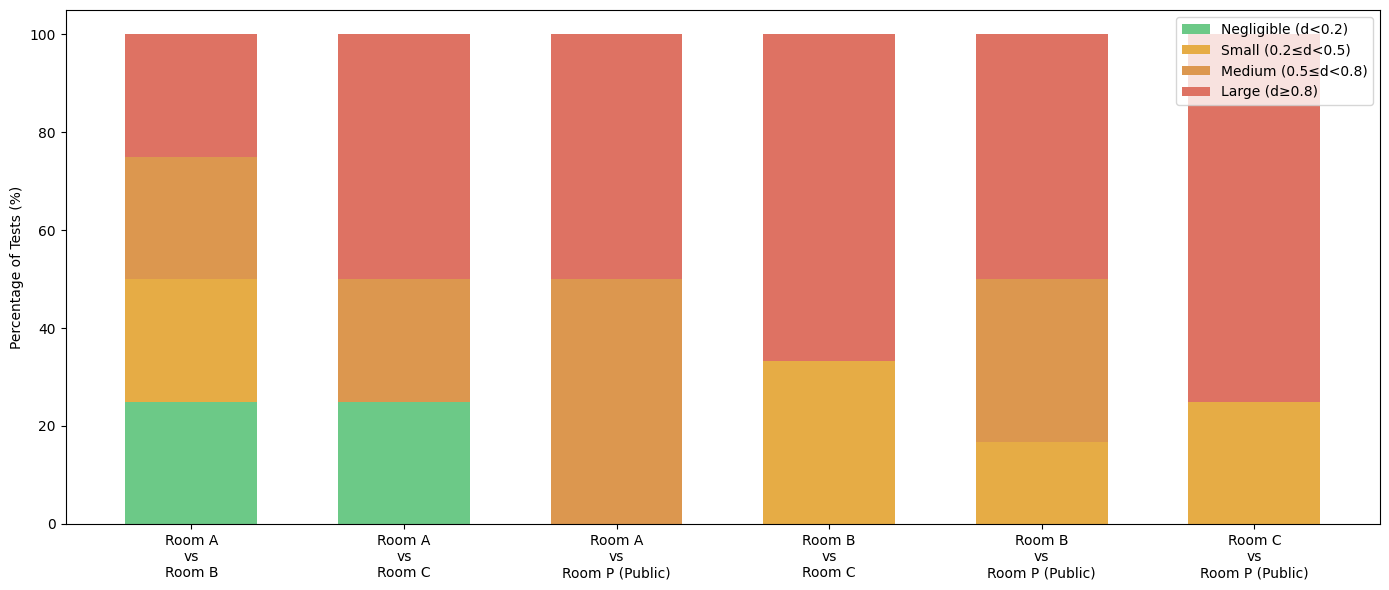


██████████████████████████████████████████████████████████████████████████████████████████████████████████████
██  METHOD 2: CONDITIONAL KS TEST  (KS on X|Y=c, FDR)
██████████████████████████████████████████████████████████████████████████████████████████████████████████████

KS SUMMARY (BH-FDR)
  Pair                               n1     n2     Tests  Sig p<.05     Sig FDR       AvgKS   MaxKS   Verdict
----------------------------------------------------------------------------------------------------------------------------------
  Room A vs Room B                   726    726    4        3/4  ( 75%)   2/4  ( 50%) 0.423   0.761   MODERATE CONDITIONAL SHIFT
  Room A vs Room C                   727    727    4        4/4  (100%)   4/4  (100%) 0.427   0.564   STRONG CONDITIONAL SHIFT
  Room A vs Room P (Public)          727    727    4        4/4  (100%)   4/4  (100%) 0.643   0.942   STRONG CONDITIONAL SHIFT
  Room B vs Room C                   726    726    6        6/6  (100%)   6/6 

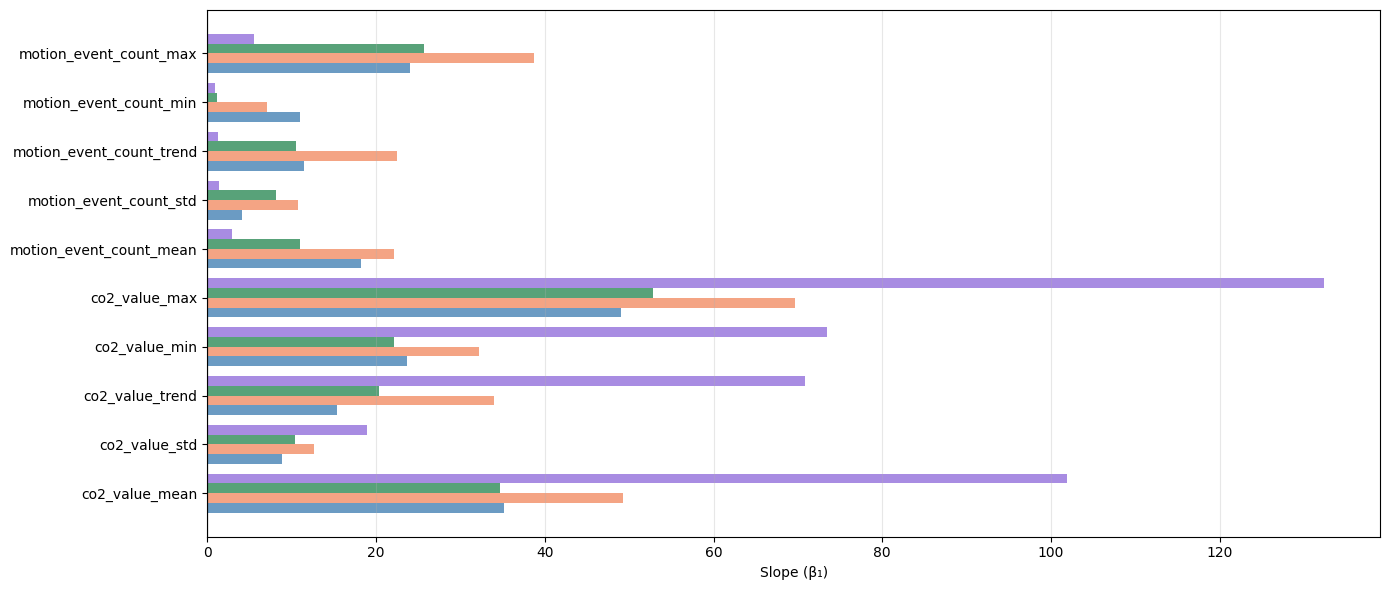

Saved figure: /opt/domain-adaptation-people-counting/results/conditional_shift/regression_lines_mean_features.png


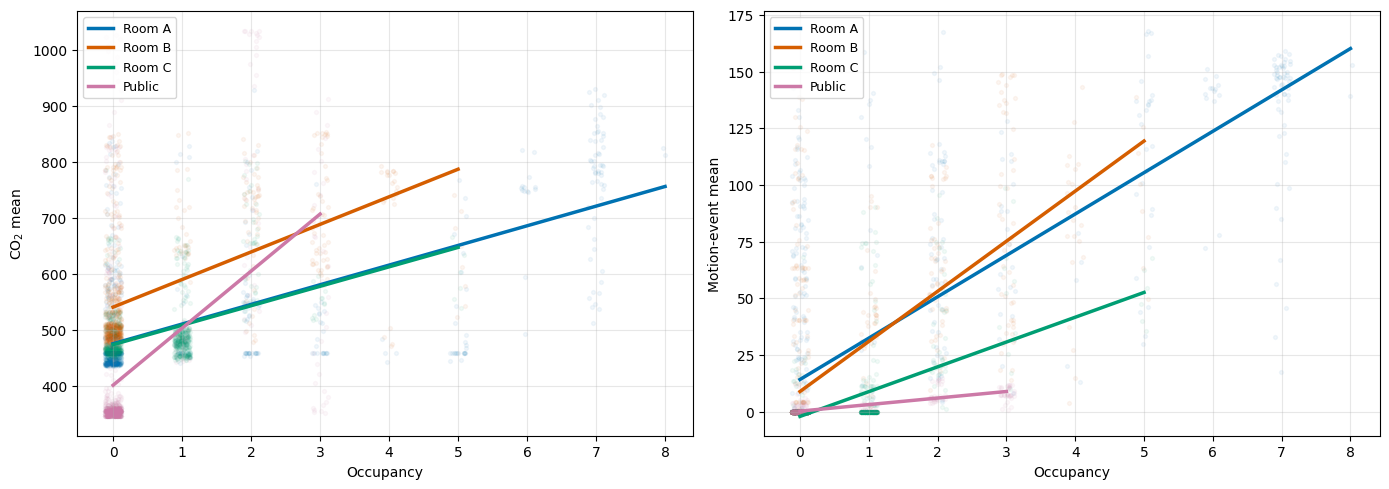


██████████████████████████████████████████████████████████████████████████████████████████████████████████████
██  METHOD 4: P(Y|X) BINNED  (FDR + permutation, overlapping windows)
██████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Binning features: ['co2_value_mean', 'motion_event_count_mean']  | bins=4

P(Y|X) BINNED SUMMARY (BH-FDR + permutation)
  Pair                               Cells  Sig FDR         AvgD    MaxD    PermP     Verdict
------------------------------------------------------------------------------------------------------------------------
  Room A vs Room B                   3        2/3  ( 67%) 0.598   0.808   0.0020    STRONG P(Y|X) SHIFT
  Room A vs Room C                   4        3/4  ( 75%) 1.303   2.433   0.0020    STRONG P(Y|X) SHIFT
  Room A vs Room P (Public)          3        1/3  ( 33%) 0.337   0.586   0.0020    MODERATE P(Y|X) SHIFT
  Room B vs Room C                   3        3/3  (100%

In [4]:
# ================================================================
# Conditional Shift Detection — ALL 4 METHODS, IMPROVED VERSION
# Selected rows for Rooms A, B, C; full set (or balanced) for Public
#
# Methods:
#   1. ClassConditionalMeans           — Welch t + Cohen's d on X | Y=c
#   2. ConditionalKSTest              — KS on X | Y=c
#   3. RegressionCoefficientComparison— slope of X ~ Y differs across rooms
#   4. ConditionalPYXShiftBinned      — bin X, compare Y inside each cell (P(Y|X))
#
# Updated:
#   - Saves figures into paper_panels/
#   - Removes big in-figure titles for paper use
#   - Keeps overlapping windows
# ================================================================

import os
import ast
import warnings
import logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except ImportError:
    _HAS_SM = False


# ================================================================
# CONFIG
# ================================================================
WINDOW_SIZE = 12
FEATURES_TO_USE = ['co2_value', 'motion_event_count']
MIN_SAMPLES = 30
FDR_ALPHA = 0.05
USE_MEAN_ONLY = True
BALANCE_SAMPLE_SIZES = True
N_PERMUTATIONS = 500
RANDOM_STATE = 42

SAVE_FIGURES = True
FIGURE_DPI = 300

PROJECT_ROOT = Path.cwd().parent
FIGURE_DIR = PROJECT_ROOT / "results" / "conditional_shift"

ROOM_PATHS = {
    'A': PROJECT_ROOT / "data" / "our_dataset" / "room_a" / "clean_data_final.csv",
    'B': PROJECT_ROOT / "data" / "our_dataset" / "room_b" / "clean_data_final.csv",
    'C': PROJECT_ROOT / "data" / "our_dataset" / "room_c" / "clean_data_final.csv"
}
PUBLIC_PATH = PROJECT_ROOT / "data" / "public_data" / "public_room_5min.csv"

SELECTED_ROWS = {
    'A': (44027, 45081),
    'B': (40027, 41081),
    'C': (21995, 23049),
    'P': None
}

SCENARIOS = {
    'A': 'scenario_2',
    'B': 'scenario_1',
    'C': 'scenario_2',
    'P': 'scenario_2'
}


# ================================================================
# SHARED UTILITIES
# ================================================================
def get_train_split(df, scenario):
    n = len(df)

    if scenario == "scenario_1":
        train_end = int(0.7 * n)
        return df.iloc[:train_end].reset_index(drop=True)

    elif scenario == "scenario_2":
        train_start = int(0.3 * n)
        return df.iloc[train_start:].reset_index(drop=True)
        return np.column_stack(cols), names


# ================================================================
# METHOD 1
# ================================================================
class ClassConditionalMeans:
    def __init__(self, dl, min_samples=MIN_SAMPLES,
                 balance=BALANCE_SAMPLE_SIZES, fdr_alpha=FDR_ALPHA,
                 random_state=RANDOM_STATE):
        self.dl = dl
        self.min_samples = min_samples
        self.balance = balance
        self.fdr_alpha = fdr_alpha
        self.rng = np.random.default_rng(random_state)
        self.all_results = {}
        self.all_summaries = []

    def _compare(self, X1, y1, X2, y2, feat_names):
        if self.balance:
            X1, y1, X2, y2 = _balance_pair(X1, y1, X2, y2, self.rng)

        common = sorted(set(np.round(y1).astype(int)) & set(np.round(y2).astype(int)))
        rows = []

        for c in common:
            m1 = (np.round(y1).astype(int) == c)
            m2 = (np.round(y2).astype(int) == c)

            if m1.sum() < self.min_samples or m2.sum() < self.min_samples:
                continue

            for fi, fn in enumerate(feat_names):
                d1 = X1[m1, fi]
                d2 = X2[m2, fi]

                t, p = stats.ttest_ind(d1, d2, equal_var=False)
                pooled = np.sqrt((d1.std() ** 2 + d2.std() ** 2) / 2)
                d = abs(d1.mean() - d2.mean()) / pooled if pooled > 0 else 0.0

                eff = (
                    "Negligible" if d < 0.2 else
                    "Small" if d < 0.5 else
                    "Medium" if d < 0.8 else
                    "Large"
                )

                rows.append({
                    'occupancy': c,
                    'feature': fn,
                    'n1': int(m1.sum()),
                    'n2': int(m2.sum()),
                    'mean1': d1.mean(),
                    'mean2': d2.mean(),
                    'std1': d1.std(),
                    'std2': d2.std(),
                    't_stat': t,
                    'p_value': p,
                    'cohens_d': d,
                    'effect_size': eff
                })

        df = pd.DataFrame(rows)
        if len(df):
            p_adj, rej = _bh_fdr(df['p_value'].values, self.fdr_alpha)
            df['p_fdr'] = p_adj
            df['sig_fdr'] = rej

        return df, len(y1), len(y2)

    def run_all(self):
        print("\n" + "█" * 110)
        print("██  METHOD 1: CLASS-CONDITIONAL MEANS  (Welch t + Cohen's d, FDR)")
        print("█" * 110)

        rooms = self.dl.rooms_data
        feat_names = self.dl.get_feature_names()

        for pair in self.dl.get_room_pairs():
            r1, r2 = pair['room1'], pair['room2']

            X1 = self.dl.get_X_window_subset(r1)
            y1 = rooms[r1]['y_seq']
            X2 = self.dl.get_X_window_subset(r2)
            y2 = rooms[r2]['y_seq']

            df, n1, n2 = self._compare(X1, y1, X2, y2, feat_names)
            self.all_results[f"{r1}_vs_{r2}"] = df

            if not len(df):
                self.all_summaries.append({
                    **pair, 'n1': n1, 'n2': n2,
                    'verdict': 'INSUFFICIENT DATA',
                    'sig_pct': 0, 'fdr_pct': 0, 'total': 0,
                    'large': 0, 'avg_d': 0.0, 'max_d': 0.0
                })
                continue

            total = len(df)
            sig = int((df['p_value'] < 0.05).sum())
            sig_fdr = int(df['sig_fdr'].sum())
            large = int((df['cohens_d'] >= 0.8).sum())
            avg_d = df['cohens_d'].mean()
            max_d = df['cohens_d'].max()

            if avg_d >= 0.5 and sig_fdr / total > 0.5:
                v = "STRONG CONDITIONAL SHIFT"
            elif avg_d >= 0.3 and sig_fdr / total > 0.2:
                v = "MODERATE CONDITIONAL SHIFT"
            elif max_d >= 0.3 or sig / total > 0.5:
                v = "WEAK CONDITIONAL SHIFT"
            else:
                v = "NO CONDITIONAL SHIFT"

            self.all_summaries.append({
                **pair,
                'n1': n1,
                'n2': n2,
                'total': total,
                'sig_raw': sig,
                'sig_pct': 100 * sig / total,
                'sig_fdr': sig_fdr,
                'fdr_pct': 100 * sig_fdr / total,
                'large': large,
                'avg_d': avg_d,
                'max_d': max_d,
                'verdict': v
            })

    def print_summary(self):
        print("\n" + "=" * 130)
        print("CCM SUMMARY (BH-FDR)")
        print("=" * 130)
        print(f"  {'Pair':<35}{'n1':<7}{'n2':<7}{'Tests':<7}{'Sig p<.05':<14}"
              f"{'Sig FDR':<14}{'AvgD':<8}{'MaxD':<8}Verdict")
        print("-" * 130)

        for s in self.all_summaries:
            comp = f"{s['r1_label']} vs {s['r2_label']}"
            if s.get('total', 0) == 0:
                print(f"  {comp:<35}{s['n1']:<7}{s['n2']:<7}{'—':<7}{'—':<14}{'—':<14}"
                      f"{'—':<8}{'—':<8}{s['verdict']}")
            else:
                print(f"  {comp:<35}{s['n1']:<7}{s['n2']:<7}{s['total']:<7}"
                      f"{s['sig_raw']:>3}/{s['total']:<3}({s['sig_pct']:>3.0f}%) "
                      f"{s['sig_fdr']:>3}/{s['total']:<3}({s['fdr_pct']:>3.0f}%) "
                      f"{s['avg_d']:<8.3f}{s['max_d']:<8.3f}{s['verdict']}")

    def plot_effect_size_distribution(self, filename="ccm_effect_size_distribution.png"):
        if not self.all_results:
            print("No CCM results to plot.")
            return

        labels = []
        negligible, small, medium, large = [], [], [], []

        for s in self.all_summaries:
            key = f"{s['room1']}_vs_{s['room2']}"
            if key not in self.all_results:
                continue

            df = self.all_results[key]
            if len(df) == 0:
                continue

            total = len(df)
            labels.append(f"{s['r1_label']}\nvs\n{s['r2_label']}")
            negligible.append((df['cohens_d'] < 0.2).sum() / total * 100)
            small.append(((df['cohens_d'] >= 0.2) & (df['cohens_d'] < 0.5)).sum() / total * 100)
            medium.append(((df['cohens_d'] >= 0.5) & (df['cohens_d'] < 0.8)).sum() / total * 100)
            large.append((df['cohens_d'] >= 0.8).sum() / total * 100)

        if not labels:
            print("No valid CCM results to plot.")
            return

        x = np.arange(len(labels))
        width = 0.62

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.bar(x, negligible, width, label='Negligible (d<0.2)', color='#6cc987')
        ax.bar(x, small, width, bottom=negligible, label='Small (0.2≤d<0.5)', color='#e6ac45')
        ax.bar(
            x, medium, width,
            bottom=np.array(negligible) + np.array(small),
            label='Medium (0.5≤d<0.8)', color='#dc974f'
        )
        ax.bar(
            x, large, width,
            bottom=np.array(negligible) + np.array(small) + np.array(medium),
            label='Large (d≥0.8)', color='#de7263'
        )

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel("Percentage of Tests (%)")
        ax.set_ylim(0, 105)
        ax.legend(loc='upper right')

        plt.tight_layout()
        _save_figure(fig, filename)
        plt.show()


# ================================================================
# METHOD 2
# ================================================================
class ConditionalKSTest:
    def __init__(self, dl, min_samples=MIN_SAMPLES,
                 balance=BALANCE_SAMPLE_SIZES, fdr_alpha=FDR_ALPHA,
                 random_state=RANDOM_STATE):
        self.dl = dl
        self.min_samples = min_samples
        self.balance = balance
        self.fdr_alpha = fdr_alpha
        self.rng = np.random.default_rng(random_state)
        self.all_results = {}
        self.all_summaries = []

    def _compare(self, X1, y1, X2, y2, feat_names):
        if self.balance:
            X1, y1, X2, y2 = _balance_pair(X1, y1, X2, y2, self.rng)

        common = sorted(set(np.round(y1).astype(int)) & set(np.round(y2).astype(int)))
        rows = []

        for c in common:
            m1 = (np.round(y1).astype(int) == c)
            m2 = (np.round(y2).astype(int) == c)

            if m1.sum() < self.min_samples or m2.sum() < self.min_samples:
                continue

            for fi, fn in enumerate(feat_names):
                d1 = X1[m1, fi]
                d2 = X2[m2, fi]

                ks, p = stats.ks_2samp(d1, d2)
                eff = (
                    "Negligible" if ks < 0.1 else
                    "Small" if ks < 0.2 else
                    "Medium" if ks < 0.4 else
                    "Large"
                )

                rows.append({
                    'occupancy': c,
                    'feature': fn,
                    'n1': int(m1.sum()),
                    'n2': int(m2.sum()),
                    'mean1': d1.mean(),
                    'mean2': d2.mean(),
                    'std1': d1.std(),
                    'std2': d2.std(),
                    'ks_stat': ks,
                    'p_value': p,
                    'effect_size': eff
                })

        df = pd.DataFrame(rows)
        if len(df):
            p_adj, rej = _bh_fdr(df['p_value'].values, self.fdr_alpha)
            df['p_fdr'] = p_adj
            df['sig_fdr'] = rej

        return df, len(y1), len(y2)

    def run_all(self):
        print("\n" + "█" * 110)
        print("██  METHOD 2: CONDITIONAL KS TEST  (KS on X|Y=c, FDR)")
        print("█" * 110)

        rooms = self.dl.rooms_data
        feat_names = self.dl.get_feature_names()

        for pair in self.dl.get_room_pairs():
            r1, r2 = pair['room1'], pair['room2']

            X1 = self.dl.get_X_window_subset(r1)
            y1 = rooms[r1]['y_seq']
            X2 = self.dl.get_X_window_subset(r2)
            y2 = rooms[r2]['y_seq']

            df, n1, n2 = self._compare(X1, y1, X2, y2, feat_names)
            self.all_results[f"{r1}_vs_{r2}"] = df

            if not len(df):
                self.all_summaries.append({
                    **pair, 'n1': n1, 'n2': n2,
                    'total': 0, 'verdict': 'INSUFFICIENT DATA',
                    'sig_pct': 0, 'fdr_pct': 0,
                    'avg_ks': 0.0, 'max_ks': 0.0
                })
                continue

            total = len(df)
            sig = int((df['p_value'] < 0.05).sum())
            sig_fdr = int(df['sig_fdr'].sum())
            avg_ks = df['ks_stat'].mean()
            max_ks = df['ks_stat'].max()
            large = int((df['ks_stat'] >= 0.4).sum())

            if avg_ks >= 0.25 and sig_fdr / total > 0.5:
                v = "STRONG CONDITIONAL SHIFT"
            elif avg_ks >= 0.15 and sig_fdr / total > 0.2:
                v = "MODERATE CONDITIONAL SHIFT"
            elif max_ks >= 0.2 or sig / total > 0.5:
                v = "WEAK CONDITIONAL SHIFT"
            else:
                v = "NO CONDITIONAL SHIFT"

            self.all_summaries.append({
                **pair,
                'n1': n1,
                'n2': n2,
                'total': total,
                'sig_raw': sig,
                'sig_pct': 100 * sig / total,
                'sig_fdr': sig_fdr,
                'fdr_pct': 100 * sig_fdr / total,
                'large': large,
                'avg_ks': avg_ks,
                'max_ks': max_ks,
                'verdict': v
            })

    def print_summary(self):
        print("\n" + "=" * 130)
        print("KS SUMMARY (BH-FDR)")
        print("=" * 130)
        print(f"  {'Pair':<35}{'n1':<7}{'n2':<7}{'Tests':<7}{'Sig p<.05':<14}"
              f"{'Sig FDR':<14}{'AvgKS':<8}{'MaxKS':<8}Verdict")
        print("-" * 130)

        for s in self.all_summaries:
            comp = f"{s['r1_label']} vs {s['r2_label']}"
            if s.get('total', 0) == 0:
                print(f"  {comp:<35}{s['n1']:<7}{s['n2']:<7}{'—':<7}{'—':<14}"
                      f"{'—':<14}{'—':<8}{'—':<8}{s['verdict']}")
            else:
                print(f"  {comp:<35}{s['n1']:<7}{s['n2']:<7}{s['total']:<7}"
                      f"{s['sig_raw']:>3}/{s['total']:<3}({s['sig_pct']:>3.0f}%) "
                      f"{s['sig_fdr']:>3}/{s['total']:<3}({s['fdr_pct']:>3.0f}%) "
                      f"{s['avg_ks']:<8.3f}{s['max_ks']:<8.3f}{s['verdict']}")


# ================================================================
# METHOD 3
# ================================================================
class RegressionCoefficientComparison:
    def __init__(self, dl, balance=BALANCE_SAMPLE_SIZES,
                 fdr_alpha=FDR_ALPHA, random_state=RANDOM_STATE):
        self.dl = dl
        self.balance = balance
        self.fdr_alpha = fdr_alpha
        self.rng = np.random.default_rng(random_state)
        self.all_results = {}
        self.all_summaries = []
        self.room_regressions = {}

    @staticmethod
    def _fit(X_feat, y):
        slope, intercept, r, p, se = stats.linregress(y, X_feat)
        return slope, intercept, se, r ** 2, p

    def _compute_room_fits(self):
        for r in self.dl.available_rooms:
            X = self.dl.get_X_window_subset(r, mean_only=False)
            y = self.dl.rooms_data[r]['y_seq']
            self.room_regressions[r] = {}

            for fi, fn in enumerate(self.dl.get_feature_names(mean_only=False)):
                slope, inter, se, r2, p = self._fit(X[:, fi], y)
                self.room_regressions[r][fn] = {
                    'slope': slope,
                    'intercept': inter,
                    'se': se,
                    'r2': r2,
                    'p': p,
                }

    def _compare(self, X1, y1, X2, y2, feat_names):
        if self.balance:
            X1, y1, X2, y2 = _balance_pair(X1, y1, X2, y2, self.rng)

        rows = []
        for fi, fn in enumerate(feat_names):
            s1, i1, se1, r21, _ = self._fit(X1[:, fi], y1)
            s2, i2, se2, r22, _ = self._fit(X2[:, fi], y2)

            se_d = np.sqrt(se1 ** 2 + se2 ** 2)
            if se_d > 0:
                z = (s1 - s2) / se_d
                p = 2 * (1 - stats.norm.cdf(abs(z)))
            else:
                z, p = 0.0, 1.0

            rows.append({
                'feature': fn,
                'n1': len(y1),
                'n2': len(y2),
                'slope1': s1,
                'slope2': s2,
                'slope_diff': abs(s1 - s2),
                'se1': se1,
                'se2': se2,
                'intercept1': i1,
                'intercept2': i2,
                'r2_1': r21,
                'r2_2': r22,
                'z_stat': z,
                'p_value': p
            })

        df = pd.DataFrame(rows)
        if len(df):
            p_adj, rej = _bh_fdr(df['p_value'].values, self.fdr_alpha)
            df['p_fdr'] = p_adj
            df['sig_fdr'] = rej

        return df, len(y1), len(y2)

    def run_all(self):
        print("\n" + "█" * 110)
        print("██  METHOD 3: REGRESSION SLOPE Z-TEST  (X = β0 + β1·Y, FDR)")
        print("█" * 110)

        self._compute_room_fits()
        rooms = self.dl.rooms_data
        feat_names = self.dl.get_feature_names(mean_only=False)

        for pair in self.dl.get_room_pairs():
            r1, r2 = pair['room1'], pair['room2']

            X1 = self.dl.get_X_window_subset(r1, mean_only=False)
            y1 = rooms[r1]['y_seq']
            X2 = self.dl.get_X_window_subset(r2, mean_only=False)
            y2 = rooms[r2]['y_seq']

            df, n1, n2 = self._compare(X1, y1, X2, y2, feat_names)
            self.all_results[f"{r1}_vs_{r2}"] = df

            total = len(df)
            sig = int((df['p_value'] < 0.05).sum())
            sig_fdr = int(df['sig_fdr'].sum())

            if total == 0:
                v = "INSUFFICIENT DATA"
            elif sig_fdr / total > 0.5:
                v = "STRONG CONDITIONAL SHIFT"
            elif sig_fdr / total > 0.2:
                v = "MODERATE CONDITIONAL SHIFT"
            elif sig / total > 0.5:
                v = "WEAK CONDITIONAL SHIFT"
            else:
                v = "NO CONDITIONAL SHIFT"

            self.all_summaries.append({
                **pair,
                'n1': n1,
                'n2': n2,
                'total': total,
                'sig_raw': sig,
                'sig_pct': 100 * sig / max(total, 1),
                'sig_fdr': sig_fdr,
                'fdr_pct': 100 * sig_fdr / max(total, 1),
                'verdict': v
            })

    def print_summary(self):
        print("\n" + "=" * 130)
        print("REGRESSION SUMMARY (BH-FDR)")
        print("=" * 130)
        print(f"  {'Pair':<35}{'n1':<7}{'n2':<7}{'Feats':<7}{'Sig p<.05':<14}"
              f"{'Sig FDR':<14}Verdict")
        print("-" * 110)

        for s in self.all_summaries:
            comp = f"{s['r1_label']} vs {s['r2_label']}"
            if s['total'] == 0:
                print(f"  {comp:<35}{s['n1']:<7}{s['n2']:<7}{'—':<7}{'—':<14}{'—':<14}{s['verdict']}")
            else:
                print(f"  {comp:<35}{s['n1']:<7}{s['n2']:<7}{s['total']:<7}"
                      f"{s['sig_raw']:>3}/{s['total']:<3}({s['sig_pct']:>3.0f}%) "
                      f"{s['sig_fdr']:>3}/{s['total']:<3}({s['fdr_pct']:>3.0f}%) "
                      f"{s['verdict']}")

    def plot_slope_comparison_bars(self,
                                   filename="regression_slope_comparison_bars.png",
                                   show_legend=False):
        if not self.room_regressions:
            print("Run regression first.")
            return

        feature_names = self.dl.get_feature_names(mean_only=False)
        rooms = self.dl.available_rooms
        n_rooms = len(rooms)
        n_feats = len(feature_names)
        colors = ['steelblue', '#f28e66', 'seagreen', 'mediumpurple']

        fig, ax = plt.subplots(figsize=(14, max(6, n_feats * 0.6)))
        y_pos = np.arange(n_feats)
        bar_h = 0.8 / n_rooms

        for r_idx, room_id in enumerate(rooms):
            room_label = f"Room {room_id}" if room_id != 'P' else "Public"
            slopes = [self.room_regressions[room_id][f]['slope'] for f in feature_names]

            ax.barh(
                y_pos + r_idx * bar_h,
                slopes,
                bar_h,
                label=room_label,
                color=colors[r_idx % len(colors)],
                alpha=0.8
            )

        ax.set_yticks(y_pos + bar_h * (n_rooms - 1) / 2)
        ax.set_yticklabels(feature_names, fontsize=10)
        ax.set_xlabel("Slope (β₁)")
        ax.axvline(x=0, color='black', linewidth=0.8)
        ax.grid(True, axis='x', alpha=0.3)

        if show_legend:
            ax.legend(frameon=True)

        plt.tight_layout()
        _save_figure(fig, filename)
        plt.show()

    def plot_regression_lines_means_only(self,
                                         filename="regression_lines_mean_features.png",
                                         show_legend=True):
        """
        Plot only:
          1) co2_value_mean
          2) motion_event_count_mean

        Figure is saved to paper_panels.
        No title is added inside the image.
        """
        if not self.room_regressions:
            print("Run regression first.")
            return

        rooms = self.dl.rooms_data
        available = self.dl.available_rooms
        feature_names = self.dl.get_feature_names(mean_only=False)
        colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']

        target_feats = ['co2_value_mean', 'motion_event_count_mean']
        target_feats = [f for f in target_feats if f in feature_names]

        if len(target_feats) == 0:
            print("Mean features not found.")
            return

        fig, axes = plt.subplots(1, len(target_feats), figsize=(14, 5))
        if len(target_feats) == 1:
            axes = [axes]

        for ax, feat_name in zip(axes, target_feats):
            feat_idx = feature_names.index(feat_name)

            for r_idx, room_id in enumerate(available):
                room_label = f"Room {room_id}" if room_id != 'P' else "Public"
                X = rooms[room_id]['X_window'][:, feat_idx]
                y = rooms[room_id]['y_seq']

                y_jitter = y + np.random.uniform(-0.12, 0.12, size=len(y))

                ax.scatter(
                    y_jitter,
                    X,
                    alpha=0.05,
                    s=8,
                    color=colors[r_idx % len(colors)]
                )

                slope = self.room_regressions[room_id][feat_name]['slope']
                intercept = self.room_regressions[room_id][feat_name]['intercept']

                x_line = np.linspace(y.min(), y.max(), 100)
                y_line = intercept + slope * x_line

                ax.plot(
                    x_line,
                    y_line,
                    color=colors[r_idx % len(colors)],
                    linewidth=2.5,
                    label=room_label
                )

            ax.set_xlabel("Occupancy")
            ax.set_ylabel("CO$_2$ mean" if feat_name == "co2_value_mean" else "Motion-event mean")
            ax.set_title("")
            ax.grid(True, alpha=0.3)

            if show_legend:
                ax.legend(fontsize=9, loc="upper left", frameon=True)

        plt.tight_layout()
        _save_figure(fig, filename)
        plt.show()

   


# ================================================================
# METHOD 4
# ================================================================
class ConditionalPYXShiftBinned:
    def __init__(self, dl, n_bins=4, min_samples=MIN_SAMPLES,
                 fdr_alpha=FDR_ALPHA, n_permutations=N_PERMUTATIONS,
                 balance=BALANCE_SAMPLE_SIZES, random_state=RANDOM_STATE):
        self.dl = dl
        self.n_bins = n_bins
        self.min_samples = min_samples
        self.fdr_alpha = fdr_alpha
        self.n_permutations = n_permutations
        self.balance = balance
        self.rng = np.random.default_rng(random_state)
        self.all_results = {}
        self.all_summaries = {}

    @staticmethod
    def _qbin(x, edges):
        return np.clip(np.digitize(x, edges[1:-1]), 0, len(edges) - 2)

    def _build_bins(self, X1, X2, feat_idx):
        pooled = np.vstack([X1, X2])
        edges_list = []

        for fi in feat_idx:
            e = np.unique(np.quantile(pooled[:, fi], np.linspace(0, 1, self.n_bins + 1)))
            if len(e) < 3:
                mn, mx, md = pooled[:, fi].min(), pooled[:, fi].max(), pooled[:, fi].mean()
                e = np.array([mn, md, mx + 1e-9])
            edges_list.append(e)

        def cells(X):
            cols = [self._qbin(X[:, fi], e) for fi, e in zip(feat_idx, edges_list)]
            return list(zip(*cols))

        return cells(X1), cells(X2)

    def _cell_stats(self, ids1, ids2, y1, y2):
        ids1_s = [str(c) for c in ids1]
        ids2_s = [str(c) for c in ids2]
        s1 = pd.Series(ids1_s, dtype="object")
        s2 = pd.Series(ids2_s, dtype="object")
        common = sorted(set(ids1_s) & set(ids2_s))
        rows = []

        for c in common:
            m1 = (s1 == c).values
            m2 = (s2 == c).values

            if m1.sum() < self.min_samples or m2.sum() < self.min_samples:
                continue

            y1c = y1[m1]
            y2c = y2[m2]

            ks, ks_p = stats.ks_2samp(y1c, y2c)
            t, t_p = stats.ttest_ind(y1c, y2c, equal_var=False)
            pooled = np.sqrt((y1c.std() ** 2 + y2c.std() ** 2) / 2)
            d = abs(y1c.mean() - y2c.mean()) / pooled if pooled > 0 else 0.0

            rows.append({
                'cell': c,
                'n1': int(m1.sum()),
                'n2': int(m2.sum()),
                'mean_y1': y1c.mean(),
                'mean_y2': y2c.mean(),
                'std_y1': y1c.std(),
                'std_y2': y2c.std(),
                'ks_stat': ks,
                'ks_p': ks_p,
                't_stat': t,
                't_p': t_p,
                'cohens_d': d
            })

        return pd.DataFrame(rows)

    def _perm_p(self, ids1, ids2, y1, y2):
        if self.n_permutations <= 0:
            return np.nan

        ids1_s = [str(c) for c in ids1]
        ids2_s = [str(c) for c in ids2]
        ids_all = np.asarray(ids1_s + ids2_s, dtype=object)
        y_all = np.concatenate([y1, y2])
        n1, N = len(y1), len(y_all)

        def stat(mask):
            df = pd.DataFrame({'cell': ids_all, 'y': y_all, 'r1': mask.astype(bool)})
            agg = df.groupby(['cell', 'r1'])['y'].agg(['mean', 'size']).unstack('r1')

            if agg.empty:
                return 0.0

            try:
                mT, mF = agg['mean'][True], agg['mean'][False]
                sT, sF = agg['size'][True], agg['size'][False]
            except KeyError:
                return 0.0

            valid = (sT >= self.min_samples) & (sF >= self.min_samples)
            if valid.sum() == 0:
                return 0.0

            diff = (mT[valid] - mF[valid]).abs()
            w = np.minimum(sT[valid], sF[valid]).astype(float)
            return float(np.average(diff, weights=w))

        obs = np.zeros(N, dtype=bool)
        obs[:n1] = True
        obs_stat = stat(obs)

        count = sum(
            stat(obs[self.rng.permutation(N)]) >= obs_stat
            for _ in range(self.n_permutations)
        )
        return (count + 1) / (self.n_permutations + 1)

    def run_all(self):
        print("\n" + "█" * 110)
        print("██  METHOD 4: P(Y|X) BINNED  (FDR + permutation, overlapping windows)")
        print("█" * 110)

        feat_idx = self.dl.get_feature_indices(mean_only=True)
        feat_names = [
            self.dl.rooms_data[self.dl.available_rooms[0]]['feature_names'][i]
            for i in feat_idx
        ]
        print(f"  Binning features: {feat_names}  | bins={self.n_bins}")

        for pair in self.dl.get_room_pairs():
            r1, r2 = pair['room1'], pair['room2']

            X1 = self.dl.rooms_data[r1]['X_window']
            y1 = self.dl.rooms_data[r1]['y_seq']
            X2 = self.dl.rooms_data[r2]['X_window']
            y2 = self.dl.rooms_data[r2]['y_seq']

            if self.balance:
                X1, y1, X2, y2 = _balance_pair(X1, y1, X2, y2, self.rng)

            ids1, ids2 = self._build_bins(X1, X2, feat_idx)
            df = self._cell_stats(ids1, ids2, y1, y2)

            if len(df):
                p_adj, rej = _bh_fdr(df['ks_p'].values, self.fdr_alpha)
                df['ks_p_fdr'] = p_adj
                df['sig_ks_fdr'] = rej

            perm_p = self._perm_p(ids1, ids2, y1, y2)
            self.all_results[f"{r1}_vs_{r2}"] = df

            if not len(df):
                self.all_summaries[f"{r1}_vs_{r2}"] = {
                    **pair,
                    'n_cells': 0,
                    'avg_d': 0.0,
                    'max_d': 0.0,
                    'sig_fdr_pct': 0.0,
                    'perm_p': perm_p,
                    'verdict': 'INSUFFICIENT DATA'
                }
                continue

            total = len(df)
            sig_fdr = int(df['sig_ks_fdr'].sum())
            avg_d = df['cohens_d'].mean()
            max_d = df['cohens_d'].max()
            fdr_pct = 100 * sig_fdr / total

            if avg_d >= 0.5 and perm_p is not None and perm_p < 0.05:
                v = "STRONG P(Y|X) SHIFT"
            elif avg_d >= 0.3 and ((perm_p is not None and perm_p < 0.05) or fdr_pct > 20):
                v = "MODERATE P(Y|X) SHIFT"
            elif max_d >= 0.3 or (perm_p is not None and perm_p < 0.05):
                v = "WEAK P(Y|X) SHIFT"
            else:
                v = "NO P(Y|X) SHIFT"

            self.all_summaries[f"{r1}_vs_{r2}"] = {
                **pair,
                'n_cells': total,
                'sig_fdr': sig_fdr,
                'sig_fdr_pct': fdr_pct,
                'avg_d': avg_d,
                'max_d': max_d,
                'perm_p': perm_p,
                'verdict': v
            }

    def print_summary(self):
        print("\n" + "=" * 130)
        print("P(Y|X) BINNED SUMMARY (BH-FDR + permutation)")
        print("=" * 130)
        print(f"  {'Pair':<35}{'Cells':<7}{'Sig FDR':<16}{'AvgD':<8}{'MaxD':<8}"
              f"{'PermP':<10}Verdict")
        print("-" * 120)

        for _, s in self.all_summaries.items():
            comp = f"{s['r1_label']} vs {s['r2_label']}"
            if s['n_cells'] == 0:
                pp = s.get('perm_p', float('nan'))
                pp_str = f"{pp:.4f}" if pp is not None and not np.isnan(pp) else "—"
                print(f"  {comp:<35}{'—':<7}{'—':<16}{'—':<8}{'—':<8}{pp_str:<10}{s['verdict']}")
            else:
                pp = s.get('perm_p')
                pstr = f"{pp:.4f}" if pp is not None and not np.isnan(pp) else "—"
                print(f"  {comp:<35}{s['n_cells']:<7}"
                      f"{s['sig_fdr']:>3}/{s['n_cells']:<3}({s['sig_fdr_pct']:>3.0f}%) "
                      f"{s['avg_d']:<8.3f}{s['max_d']:<8.3f}{pstr:<10}{s['verdict']}")


# ================================================================
# COMBINED SUMMARY
# ================================================================
def print_combined_summary(ccm, ks, reg, pyx):
    print("\n" + "█" * 130)
    print("██  COMBINED CONDITIONAL SHIFT SUMMARY — ALL 4 METHODS (FDR-corrected)")
    print("█" * 130)

    pairs = ccm.dl.get_room_pairs()

    print(f"\n  {'Comparison':<32}{'CCM':<28}{'KS':<28}{'Regression':<28}{'P(Y|X) Binned':<28}")
    print("  " + "-" * 145)

    for p in pairs:
        comp = f"{p['r1_label']} vs {p['r2_label']}"
        ccm_v = next((s['verdict'] for s in ccm.all_summaries
                      if s['room1'] == p['room1'] and s['room2'] == p['room2']), "—")
        ks_v = next((s['verdict'] for s in ks.all_summaries
                     if s['room1'] == p['room1'] and s['room2'] == p['room2']), "—")
        reg_v = next((s['verdict'] for s in reg.all_summaries
                      if s['room1'] == p['room1'] and s['room2'] == p['room2']), "—")
        pyx_s = pyx.all_summaries.get(f"{p['room1']}_vs_{p['room2']}", {})
        pyx_v = pyx_s.get('verdict', "—")

        print(f"  {comp:<32}{ccm_v:<28}{ks_v:<28}{reg_v:<28}{pyx_v:<28}")

    print("\n" + "=" * 130)
    print("TRANSFER RECOMMENDATION (votes across 4 methods)")
    print("=" * 130)

    for p in pairs:
        comp = f"{p['r1_label']} ↔ {p['r2_label']}"
        tag = "[CROSS]" if p['is_cross_domain'] else "[SAME]"
        score = 0

        for collection in [ccm.all_summaries, ks.all_summaries, reg.all_summaries]:
            s = next((x for x in collection if x['room1'] == p['room1']
                      and x['room2'] == p['room2']), None)
            if s:
                if "STRONG" in s['verdict']:
                    score += 2
                elif "MODERATE" in s['verdict']:
                    score += 1

        s4 = pyx.all_summaries.get(f"{p['room1']}_vs_{p['room2']}", {})
        if "STRONG" in s4.get('verdict', ''):
            score += 2
        elif "MODERATE" in s4.get('verdict', ''):
            score += 1

        if score >= 5:
            sym, note = "✗✗", "Strong agreement: needs full adaptation (parameter-based FT or hybrid)"
        elif score >= 3:
            sym, note = "△", "Partial shift: fine-tuning or label-aware reweighting recommended"
        elif score >= 1:
            sym, note = "○", "Minor shift: caution / light reweighting"
        else:
            sym, note = "✓✓", "No conditional shift detected: direct transfer feasible"

        print(f"  {sym}  {tag:<8}{comp:<40} score={score}/8   {note}")

    print("\n  Legend: ✓✓ safe  |  ○ caution  |  △ fine-tune  |  ✗✗ adapt")
    print("=" * 130)


# ================================================================
# RUN
# ================================================================
if __name__ == "__main__":
    _prepare_figure_dir()

    loader = DataLoader(
        room_paths=ROOM_PATHS,
        public_path=PUBLIC_PATH,
        window_size=WINDOW_SIZE,
        features_to_use=FEATURES_TO_USE,
        selected_rows=SELECTED_ROWS
    )
    loader.load_all()

    # Method 1
    ccm = ClassConditionalMeans(loader)
    ccm.run_all()
    ccm.print_summary()
    ccm.plot_effect_size_distribution(
        filename="ccm_effect_size_distribution.png"
    )

    # Method 2
    ks = ConditionalKSTest(loader)
    ks.run_all()
    ks.print_summary()

    # Method 3
    reg = RegressionCoefficientComparison(loader)
    reg.run_all()
    reg.print_summary()
    reg.plot_slope_comparison_bars(
        filename="regression_slope_comparison_bars.png",
        show_legend=False
    )
    reg.plot_regression_lines_means_only(
        filename="regression_lines_mean_features.png",
        show_legend=True
    )

    # Method 4
    pyx = ConditionalPYXShiftBinned(loader)
    pyx.run_all()
    pyx.print_summary()

    # Combined
    print_combined_summary(ccm, ks, reg, pyx)